# Uvod u znanost o podacima - Projekt 3
## Replikacija i poboljšanje: *Early Predictor for Student Success* (OULAD)

Tim:
- Fran Galić (JMBAG: 0036546889)
- Jan Celin (JMBAG: 0069094271)
- Jana Gazdek (JMBAG: 0036537526)

Rad:
- [*Early Predictor for Student Success Based on Behavioural and Demographical Indicators*](https://durham-repository.worktribe.com/output/1140702/early-predictor-for-student-success-based-on-behavioural-and-demographical-indicators)

Skup podataka:
- Open University Learning Analytics Dataset (OULAD)

# 1. Uvod

## Kratko o originalnom radu
Originalni rad se bavi ranom predikcijom ishoda studenta na OULAD skupu podataka koristeći kombinaciju:
- demografskih varijabli,
- ranih ponašajnih signala (VLE/LMS aktivnosti: klikovi i aktivni dani),
- informacija o prvoj provjeri znanja (rezultat, tip, vremenske informacije).

Ciljana varijabla je višeklasna: Withdrawn / Fail / Pass / Distinction.
Za multiclass klasifikaciju rad (gdje je potrebno) koristi One-vs-Rest (OVR) pristup te uspoređuje više modela.

## Cilj ovog rada
Cilj je dvostruk:

1) Replikacija (baseline): replicirati metodologiju i ključne rezultate rada koliko je razumno moguće te argumentirano komentirati odstupanja (npr. filtriranje instanci, obrada nedostajućih vrijednosti, split, definicija feature-a).

2) Poboljšanja (iterativno): nakon baseline-a provesti niz praktičnih poboljšanja s ciljem postizanja što boljih rezultata. Poboljšanja provodimo inkrementalno (jedno po jedno) i nakon svakog koraka uspoređujemo s baseline-om / najboljim dosadašnjim modelom te kratko komentiramo učinak.

Plan poboljšanja uključuje:
- fine-tuning hiperparametara,
- dodavanje novih značajki,
- isprobavanje jačih modela (npr. Logistic Regression, SVM, boosting poput XGBoost/LightGBM/CatBoost, jednostavna neuronska mreža),
- metode rada s neuravnoteženim klasama (npr. SMOTE / upsampling).

Bonus analize: dodatno analiziramo (i) heterogenost performansi po kolegijima/prezentacijama, te (ii) utjecaj korištenja “kasnijih” informacija (više podataka od ranog stadija), ako su dostupne.

U cijelom notebooku pazimo na reproducibilnost (fiksni seedovi, isti split/validacija) i korektnu evaluaciju bez leakage-a (posebno kod resamplinga).

## Plan notebooka
1) Setup i reproducibilnost
2) Dataset i kratki EDA
3) Preprocessing i feature set (ML-ready dataset)
4) Baseline replikacija (naša referenca)
5) Iterativna poboljšanja + odabir najboljeg modela
6) Bonus analize
7) Sažetak rezultata + diskusija + zaključak  

# 2. Setup i reproducibilnost

U ovom poglavlju “zaključavamo” uvjete pokusa kako bi rezultati bili ponovljivi.

## Okruženje
Notebook je izrađen tako da bude reproducibilan kroz:
- Python 3.11 (lokalni `uv` environment)
- `pyproject.toml` + `uv.lock` (zaključane verzije paketa)
- fiksirane seedove za slučajnost (NumPy + modeli u scikit-learnu)

## Zašto je reproducibilnost bitna ovdje?
U radovima na OULAD-u često postoji više legitimnih odluka koje mijenjaju rezultate, npr.:
- filtriranje instanci/studenata,
- obrada nedostajućih vrijednosti (missingness),
- način train/test splita i cross-validacije,
- odabir metrika i način agregacije.

Zato u nastavku eksplicitno bilježimo:
- shape nakon učitavanja,
- distribuciju klasa,
- udjele nedostajućih vrijednosti,
- sve odluke o preprocessing-u (encoding, imputacija, scaling),
- evaluacijski protokol (split/seed, bez leakage-a).

## Struktura projekta
Pretpostavljamo sljedeći layout:
- `processed_data/early_predictors_all_features.csv` - pripremljeni skup podataka za modeliranje
- `uv.lock` i `pyproject.toml` - reproducibilno okruženje
- notebook (`.ipynb`) - eksperimenti i rezultati


In [152]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", os.sys.version.split()[0])
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)

DATA_PATH = Path("data/early_predictors_all_features.csv")
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH.resolve()}"
print("Dataset:", DATA_PATH)

Python: 3.11.0
numpy: 2.4.1
pandas: 2.3.3
sklearn: 1.8.0
Dataset: data/early_predictors_all_features.csv


# 3. Dataset i kratki EDA

U ovom poglavlju:
- učitavamo podatke i provjeravamo osnovne informacije (shape, tipovi, nedostajuće vrijednosti),
- definiramo target i skup feature-a,
- radimo minimalni EDA: distribucija klasa + brza provjera korelacija numeričkih varijabli.

Cilj EDA nije “duboka analiza”, nego provjera da razumijemo podatke i da nema očitih problema prije modeliranja. (duboku analizu smo radili u prošlom dijelu projekta)

In [153]:
data = pd.read_csv(DATA_PATH)

print("Shape:", data.shape)
display(data.head(10))
display(data.info())

Shape: (32593, 23)


,id_student,code_module,code_presentation,highest_education,age_band,gender,disability,num_of_prev_attempts,final_result,imd_band,...,first_assessment_type,score_first_assessment,delay_first_assessment,cumulative_score_half,cumulative_score_3q,clicks_till_course_starts,active_days_before_course_start,clicks_from_course_start_until_first_assessment,active_days_from_course_start_until_first_assessment,clicks_from_course_start_until_half
0,11391,AAA,2013J,HE Qualification,55<=,M,N,0,Pass,90-100%,...,TMA,78.0,-1.0,243.0,328.0,98.0,1.0,303.0,7.0,612.0
1,28400,AAA,2013J,HE Qualification,35-55,F,N,0,Pass,20-30%,...,TMA,70.0,3.0,208.0,272.0,215.0,7.0,278.0,8.0,771.0
2,30268,AAA,2013J,A Level or Equivalent,35-55,F,Y,0,Withdrawn,30-40%,...,TMA,0.0,NaN,0.0,0.0,102.0,6.0,179.0,6.0,179.0
3,31604,AAA,2013J,A Level or Equivalent,35-55,F,N,0,Pass,50-60%,...,TMA,72.0,-2.0,217.0,305.0,169.0,5.0,275.0,11.0,1213.0
4,32885,AAA,2013J,Lower Than A Level,0-35,F,N,0,Pass,50-60%,...,TMA,69.0,7.0,162.0,197.0,295.0,8.0,204.0,11.0,504.0
5,38053,AAA,2013J,A Level or Equivalent,35-55,M,N,0,Pass,80-90%,...,TMA,79.0,0.0,222.0,272.0,277.0,9.0,410.0,18.0,1035.0
6,45462,AAA,2013J,HE Qualification,0-35,M,N,0,Pass,30-40%,...,TMA,70.0,1.0,197.0,272.0,180.0,4.0,264.0,7.0,732.0
7,45642,AAA,2013J,A Level or Equivalent,0-35,F,N,0,Pass,90-100%,...,TMA,72.0,-1.0,216.0,289.0,21.0,3.0,285.0,11.0,858.0
8,52130,AAA,2013J,A Level or Equivalent,0-35,F,N,0,Pass,70-80%,...,TMA,72.0,0.0,215.0,287.0,6.0,2.0,252.0,12.0,1063.0
9,53025,AAA,2013J,Post Graduate Qualification,55<=,M,N,0,Pass,NaN,...,TMA,71.0,-10.0,229.0,309.0,176.0,5.0,320.0,10.0,1753.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 23 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   id_student                                            32593 non-null  int64  
 1   code_module                                           32593 non-null  object 
 2   code_presentation                                     32593 non-null  object 
 3   highest_education                                     32593 non-null  object 
 4   age_band                                              32593 non-null  object 
 5   gender                                                32593 non-null  object 
 6   disability                                            32593 non-null  object 
 7   num_of_prev_attempts                                  32593 non-null  int64  
 8   final_result                                          32

None

## 3.2 Opis značajki

Dataset ima 23 stupca, koje grupiramo radi jasnog objašnjenja, usporedbe modela i kontrole "ranog" vs "kasnijeg" signala.

### (A) Identifikatori i kontekst kolegija (za filtriranje / bonus analize)
- `id_student`, `code_module`, `code_presentation`

`id_student` je isključivo identifikator (ne koristimo ga kao značajku).
`code_module` i `code_presentation` ne koristimo u baseline treningu (nema one-hot encodinga), nego ih čuvamo za:
- filtriranje i usporedbu performansi po kolegijima/prezentacijama (bonus analiza),
- potencijalne course-specific eksperimente (npr. treniranje i evaluacija unutar jednog modula/prezentacije).

### (B) Demografske i socioekonomske varijable
- `highest_education`, `age_band`, `gender`, `disability`, `num_of_prev_attempts`
- `imd_band`, `region`, `studied_credits`, `date_registration`

`imd_band` i `date_registration` imaju nedostajuće vrijednosti -> u pretprocesiranju radimo imputaciju te po potrebi dodajemo indikator nedostajućnosti.
Ove varijable često nose signal, ali literatura pokazuje da demografske varijable ne povećavaju nužno performanse kada su dostupni jači signali iz aktivnosti/performansi; često su korisnije za fairness analize.
[Cohausz et al., 2023 – Investigating the Importance of Demographic Features for At-Risk Prediction (EDM 2023)](https://educationaldatamining.org/EDM2023/proceedings/2023.EDM-long-papers.11/index.html)

### (C) Prva provjera znanja (first assessment)
- `first_assessment_type`, `score_first_assessment`, `delay_first_assessment`

Ovo su jaki rani signali. Missing u `delay_first_assessment` tipično znači nije predano -> nedostanak informacije je informativan, pa ga u pretprocesiranju tretiramo kao signal (indikator + imputacija).

### (D) Ponašajne varijable (VLE/LMS aktivnosti)
- `clicks_till_course_starts`, `active_days_before_course_start`
- `clicks_from_course_start_until_first_assessment`, `active_days_from_course_start_until_first_assessment`

Ključne za ranu predikciju jer mjere angažman prije/oko prve provjere.

### (E) Kasnije agregirane značajke
- `cumulative_score_half`, `cumulative_score_3q`, `clicks_from_course_start_until_half`

Ove varijable koriste kasnije informacije u predmetima -> u inicijalnom dijelu ih držimo odvojeno, a koristimo ih za dodatno pitanje (*Imaju li podaci iz kasnijih trenutaka kolegija veću prediktivnu moć od onih korištenih u početnom istraživanju?*)

### Ciljana varijabla
- `final_result` ∈ {`Withdrawn`, `Fail`, `Pass`, `Distinction`}

Neuravnoteženost klasa adresiramo metrikama (macro-F1, balanced accuracy) i naduzorkovanjem (SMOTE).

In [154]:
TARGET = "final_result"
(data[TARGET].value_counts(normalize=True) * 100).round(2)

final_result
Pass           37.93
Withdrawn      31.16
Fail           21.64
Distinction     9.28
Name: proportion, dtype: float64

## 3.3 Nedostajuće vrijednosti (missingness)

U podacima se pojavljuju missing vrijednosti u tri varijable:
- `delay_first_assessment` (~22.1%)
- `imd_band` (~3.41%)
- `date_registration` (~0.14%)

Kod nekih varijabli missing može nositi informaciju (signal), dok je kod drugih praktično napraviti "čišćenje" ili jednostavnu imputaciju.

### `delay_first_assessment`
Udio missinga je velik (~22%) i često znači da student nije predao / nema valjani zapis prve provjere, pa “delay” ne postoji.

Zato ćemo:
- dodati indikator `has_first_assessment` (1 ako vrijednost postoji, 0 ako je missing),
- imputirati `delay_first_assessment` sentinel vrijednošću `999` kako bi modeli mogli raditi s numeričkom vrijednošću.

### `imd_band`
Iako ima umjeren udio missinga (~3.4%), ovdje ne radimo imputaciju - umjesto toga izbacujemo (dropamo) sve retke koji imaju missing vrijednost u `imd_band`.
Time dobivamo konzistentan podskup bez nedostajućih socioekonomskih oznaka.

### `date_registration`
`date_registration` ima vrlo mali udio missinga (~0.14%), pa je dovoljno:
- imputirati missing vrijednosti medijanom.

### Zaključak (baseline preprocessing)
- `date_registration` -> medijan imputacija
- `imd_band` -> drop redova s missing vrijednosti
- `delay_first_assessment` -> `has_first_assessment` + imputacija vrijednošću `999`

In [155]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing[missing > 0].round(3).to_frame("% missing"))

,% missing
delay_first_assessment,22.115
date_submitted_first,22.115
imd_band,3.409
date_registration,0.138


## 3.4 Brzi EDA

Ciljevi brzog EDA:
1) vizualizirati distribuciju klasa (da vidimo imbalance),
2) provjeriti korelacije numeričkih varijabli (npr. klikovi vs aktivni dani),
3) identificirati potencijalno redundantne varijable.

Napomena: već smo uočili relativno visoku korelaciju (~0.80) između nekih parova varijabli:
- klikovi i broj aktivnih dana prije početka kolegija,
- klikovi i broj aktivnih dana od početka do prve provjere.

To nije nužno problem za tree/boosting modele, ali može utjecati na linearne modele i interpretabilnost.

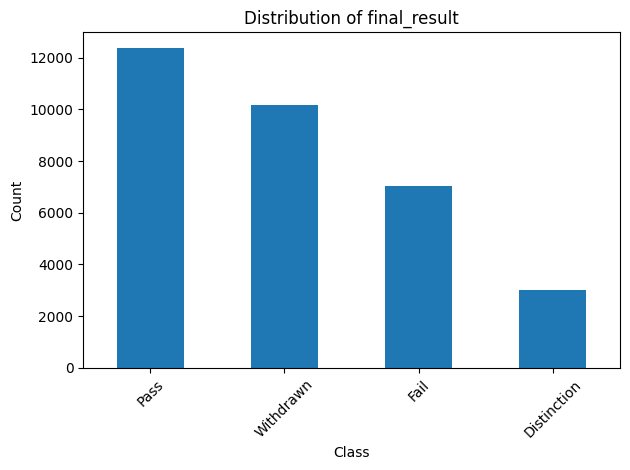

In [156]:
counts = df[TARGET].value_counts()
plt.figure()
counts.plot(kind="bar")
plt.title("Distribution of final_result")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

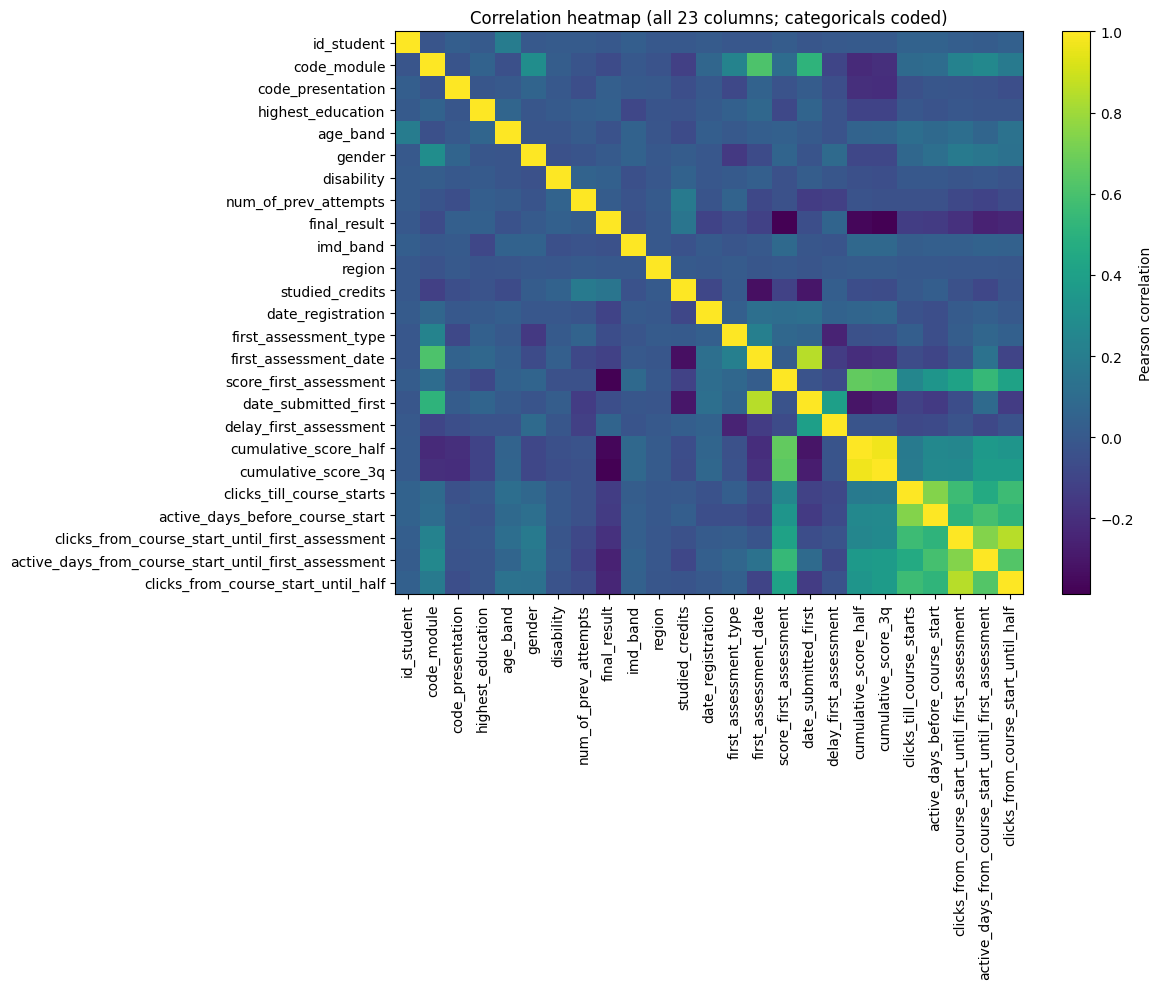

In [157]:
import matplotlib.pyplot as plt

df_corr = df.copy()

# Pretvori sve stupce u numeričku reprezentaciju (za heatmap svih 23 stupca)
# - numerički ostaju kakvi jesu
# - string/categorical -> category codes
for c in df_corr.columns:
    if df_corr[c].dtype == "object" or str(df_corr[c].dtype).startswith("string"):
        df_corr[c] = df_corr[c].astype("category").cat.codes
    # sigurnost: booleans -> int
    if df_corr[c].dtype == "bool":
        df_corr[c] = df_corr[c].astype(int)

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
im = plt.imshow(corr.values, aspect="auto")
plt.title("Correlation heatmap (all 23 columns; categoricals coded)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(im, label="Pearson correlation")
plt.tight_layout()
plt.show()


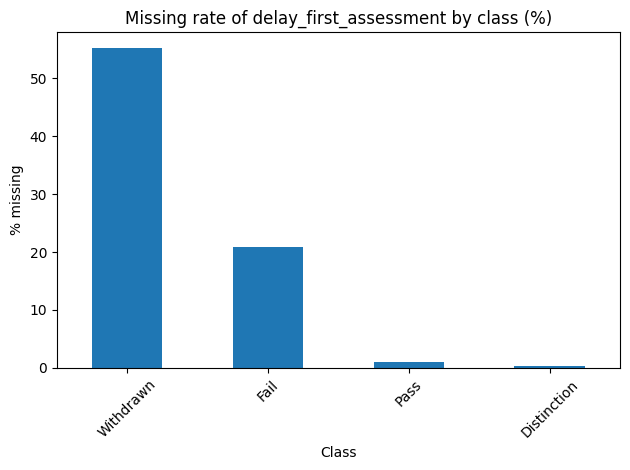

final_result
Withdrawn      55.20
Fail           20.85
Pass            1.01
Distinction     0.23
Name: delay_first_assessment, dtype: float64


In [158]:
TARGET = "final_result"
col = "delay_first_assessment"

miss_rate_by_class = df.groupby(TARGET)[col].apply(lambda s: s.isna().mean() * 100).sort_values(ascending=False)

plt.figure()
miss_rate_by_class.plot(kind="bar")
plt.title("Missing rate of delay_first_assessment by class (%)")
plt.xlabel("Class")
plt.ylabel("% missing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(miss_rate_by_class.round(2))

### Zaključci EDA-a

- Distribucija ciljne varijable pokazuje neravnotežu klasa (najviše *Pass*, najmanje *Distinction*), pa ćemo u evaluaciji naglasiti F1 score i matrice konfuzije.
- Numeričke varijable vezane uz klikove i aktivne dane pokazuju umjerenu do visoku korelaciju (≈0.8 za neke parove), što može utjecati na linearne modele i interpretabilnost, dok tree/boosting modeli to obično podnose bolje.
- Nedostajuće vrijednosti nisu “nasumične”: posebno `delay_first_assessment` vjerojatno nosi informaciju o nepredanoj prvoj provjeri. To ćemo kasnije eksplicitno testirati kroz eksperiment E3 (missingness-as-signal).
- Sljedeći korak je definiranje preprocessing pipeline-a i baseline replikacije, koji će biti referentna točka za sve eksperimente (E1–E6).

## 3. Priprema podataka
Nakon što smo uspješno učitali podatke, potrebno ih je pripremiti. To uključuje:
- micanje/zamjena nedostajućih vrijednosti  
- provjeru konstantnih i monotone varijable
- transformiranje podataka u format pogodan za modele strojnog učenja

### Čišćenje podataka
Prvo provjeravamo koje varijable imaju nedostajuće vrijednosti.


In [159]:
# Provjera nedostajućih varijabli
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0]  
print("Nedostajuće vrijednosti:")
for col, count in missing_values.items():
    print(f"{col} - {count}")


Nedostajuće vrijednosti:
imd_band - 1111
date_registration - 45
delay_first_assessment - 7208


In [160]:
data = data.dropna(subset=['imd_band'])

# Zamjena nedostajućih vrijednosti medijanom
median_value = data['date_registration'].median()
data['date_registration'] = data['date_registration'].fillna(median_value)
print(f"\nNedostajuće vrijednosti u 'date_registration' zamijenjene medijanom: {median_value}")

# Dodavanje varijable submitted_first_assignment
data['submitted_first_assignment'] = data['delay_first_assessment'].notna().astype(int)
print("\nDodana varijabla 'submitted_first_assignment' (1 = predao, 0 = nije predao)")
data['delay_first_assessment'] = data['delay_first_assessment'].fillna(999)
print(f"Nedostajuće vrijednosti u 'delay_first_assessment' zamijenjene s 999")


Nedostajuće vrijednosti u 'date_registration' zamijenjene medijanom: -57.0

Dodana varijabla 'submitted_first_assignment' (1 = predao, 0 = nije predao)
Nedostajuće vrijednosti u 'delay_first_assessment' zamijenjene s 999


Nedostajuće vrijednosti za varijablu `date_registration` zamijenjene su medijanom jer nije riječ o stvarno nedostajućim vrijednostima  Umjesto varijable `delay_first_assignment` uvodimo varijablu `submitted_first_assignment` koja nam govori je li neki student predao prvi zadatak ili ne. Originalna varijabla je imala puno nedostajućih vrijednosti, ali u ovom slučaju nismo ih mogli zamijeniti medijanom jer nam je nepostojanje te varijable označavalo neangažiranost studenta, što je bilo potrebno očuvati na drugi način. Varijabla `imd_band` također je imala nedostajuće vrijednosti te su retci s tim nedostajućim vrijednositma izbačeni (~3% redaka).

U članku se za daljnju analizu uzimaju varijable `first_assignment_mark`, `education_level`, `clicks_till_course_starts`, `registration_date`, `age`, `disability`, `gender` i  `num_of_pred_attempts`.

#### Priprema podataka za treniranje

Trenutni skup podataka ima veći broj stupaca od onoga korištenog u originalnom članku te se neke tekstualne vrijednosti trebaju mapirati u numeričke, što smo učinili u donjim isječcima koda.

In [161]:
education_map = {
    'Lower Than A Level': 0,
    'A Level or Equivalent': 1,
    'HE Qualification': 2,
    'Post Graduate Qualification': 3
}
data['highest_education'] = data['highest_education'].map(education_map)
age_map = {
    '0-35': 0,
    '35-55': 1,
    '55<=': 2
}
data['age_band'] = data['age_band'].map(age_map)
data['gender'] = data['gender'].map({'M': 0, 'F': 1})
data['disability'] = data['disability'].map({'N': 0, 'Y': 1})

data['highest_education'] = data['highest_education'].fillna(data['highest_education'].mode()[0])

In [162]:
used_features = [
    'score_first_assessment',
    'highest_education',
    'clicks_till_course_starts',
    'date_registration',
    'age_band',
    'gender',
    'disability',
    'num_of_prev_attempts',
]

y = data['final_result']
X = data[used_features]


Nakon mapiranja i izbacivanja nekorištenih stupaca, još jedanput vršimo provjeru nedostajućih vrijednosti.

In [163]:
X.notna().sum()

score_first_assessment       31482
highest_education            31482
clicks_till_course_starts    31482
date_registration            31482
age_band                     31482
gender                       31482
disability                   31482
num_of_prev_attempts         31482
dtype: int64

Nema nedostajućih vrijednosti!

In [164]:
from sklearn.model_selection import train_test_split
# Podjela na train i test skup u omjeru 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Broj uzoraka u trening skupu:", X_train.shape[0])
print("Broj uzoraka u test skupu:", X_test.shape[0])

Broj uzoraka u trening skupu: 22037
Broj uzoraka u test skupu: 9445


Nakon kodiranja i podjele skupa, podaci su spremni za treniranje modela. Ciljna varijabla je `final_result`, a varijable korištene za treniranje i testiranje modela su `first_assignment_mark`, `education_level`, `clicks_till_course_starts`, `registration_date`, `age` `disability` i `gender`. Koristimo parametar *stratify* kako bismo osigurali da omjer klasa ciljne varijable u trening i test skupu bude jednak kao u originalnom skupu podataka.  

U sljedećem koraku implementirat ćemo modele iz članka koristeći OVR klasifikaciju.

# 4. Replikacija modela iz članka
S obzirom da naša ciljna varijabla ima četiri klase, potrebno je pretvoriti naš problem u binarnu klasifikaciju kako bismo mogli zadanu ciljnu varijabli koristiti u modelima. Autori članka za to koriste _One vs. Rest_ (OVR) metodu, gdje se zapravo za svaku klasu trenira poseban binarni klasifikator po principu: ta klasa vs. ostale klase. Modeli koje implementiramo su:
- stablo odluke
- slučajna šuma
- klasifikator gradijentnog pojačavanja (kao zamjena za BART algoritam korišten u članku, budući da BART nije kompatibilan s novijim verzijama Pythona)

Svi modeli trenirani su OVR metodom i sa zadanim parametrima. Također, u članku nisu navodili nikakve detalje u vezi optimizacije hiperparametara ili inženjeringa značajki pa su uzete sve defaultne vrijednosti.

In [132]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

# Implementacije sva 3 modela
dt_model = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))
rf_model = OneVsRestClassifier(RandomForestClassifier(random_state=42))
gb_model = OneVsRestClassifier(GradientBoostingClassifier(random_state=42))

# Treniranje modela
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Testiranje modela
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

print("Gotovo treniranje i predikcija modela.")

Gotovo treniranje i predikcija modela.


### Evaluacija
Nakon treniranja i testiranja modela, slijedi evaluacija dobivenih rezultata po istom principu kako je opisano u članku radi što lakše usporedbe. Korištene metrike su: _precision (preciznost)_, _recall (odziv)_, _accuracy (točnost)_ i _F1-score (F1-mjera)_. 

In [133]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb  
}

classes = y_test.unique()
results = []

for cls in classes:
    for model_name, y_pred in models.items():
        y_test_bin = (y_test == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)
        
        prec = precision_score(y_test_bin, y_pred_bin)
        rec = recall_score(y_test_bin, y_pred_bin)
        f1 = f1_score(y_test_bin, y_pred_bin)
        acc = accuracy_score(y_test_bin, y_pred_bin)
        
        results.append({
            "Class": cls,
            "Model": model_name,
            "Precision": round(prec, 2),
            "Recall": round(rec, 2),
            "F1": round(f1, 2),
            "Accuracy": round(acc, 2)
        })
df_results = pd.DataFrame(results)

df_long = df_results.melt(
    id_vars=["Class", "Model"],
    value_vars=["Precision", "Recall", "F1", "Accuracy"],
    var_name="Metric",
    value_name="Value"
)
table = df_long.pivot_table(
    index=["Class", "Metric"],
    columns="Model",
    values="Value"
).round(2)

print(table)


Model                  Decision Tree  Gradient Boosting  Random Forest
Class       Metric                                                    
Distinction Accuracy            0.72               0.91           0.89
            F1                  0.21               0.11           0.19
            Precision           0.14               0.60           0.29
            Recall              0.42               0.06           0.14
Fail        Accuracy            0.68               0.77           0.72
            F1                  0.28               0.24           0.27
            Precision           0.28               0.44           0.32
            Recall              0.29               0.16           0.23
Pass        Accuracy            0.63               0.65           0.64
            F1                  0.44               0.66           0.60
            Precision           0.51               0.52           0.52
            Recall              0.39               0.90           0.72
Withdr

U članku je također napravljena matrica konfuzije za klasu Pass vs. rest te graf s ROC krivuljom za BART, odnosno Gradient boosting u našem slučaju i graf s ROC krivuljama za Random Forest i Decision Tree. 

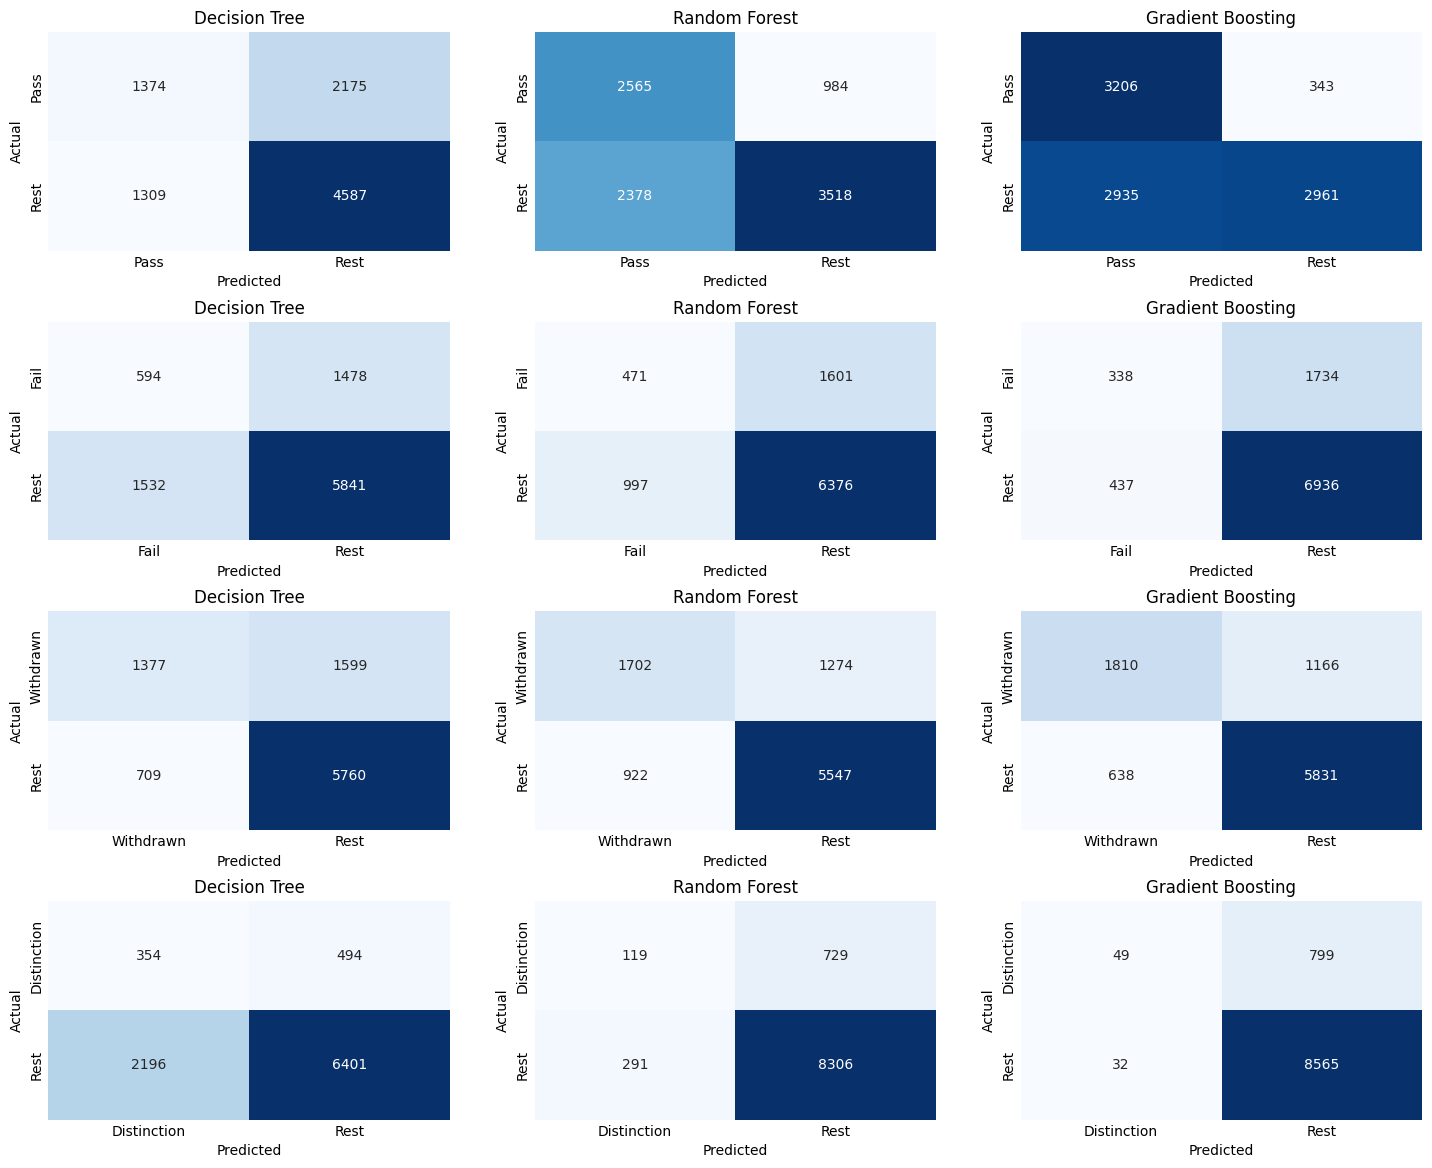

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

classes = ["Pass", "Fail", "Withdrawn", "Distinction"]

fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=len(models),
    figsize=(15, 12)
)
plt.tight_layout(pad=3.0)

for i, cls in enumerate(classes):
    y_test_bin = (y_test == cls).astype(int)

    for j, (model_name, y_pred) in enumerate(models.items()):
        y_pred_bin = (y_pred == cls).astype(int)
        cm = confusion_matrix(y_test_bin, y_pred_bin)

        TN, FP, FN, TP = cm.ravel()

        cm_plot = np.array([
            [TP, FN],
            [FP, TN]
        ])

        ax = axes[i, j]
        sns.heatmap(
            cm_plot,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=[cls, "Rest"],
            yticklabels=[cls, "Rest"],
            ax=ax
        )

        ax.set_title(f"{model_name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        # malo razmaka
        ax.tick_params(axis='both', which='both', length=0)

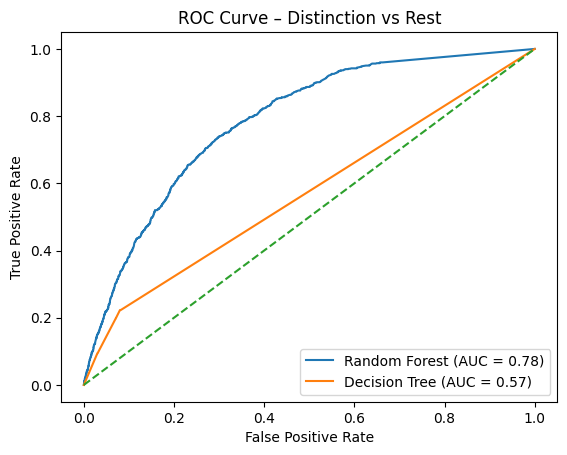

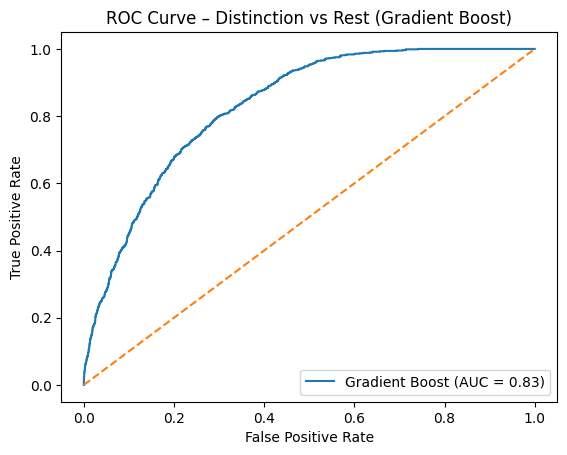

In [136]:
y_test_bin_dist = (y_test == "Distinction").astype(int)

rf_idx = list(rf_model.classes_).index("Distinction")
y_score_rf = rf_model.predict_proba(X_test)[:, rf_idx]

mask_rf = ~np.isnan(y_score_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin_dist[mask_rf], y_score_rf[mask_rf])
auc_rf = auc(fpr_rf, tpr_rf)

dt_idx = list(dt_model.classes_).index("Distinction")
y_score_dt = dt_model.predict_proba(X_test)[:, dt_idx]

mask_dt = ~np.isnan(y_score_dt)
fpr_dt, tpr_dt, _ = roc_curve(y_test_bin_dist[mask_dt], y_score_dt[mask_dt])
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Distinction vs Rest")
plt.legend()
plt.show()


gb_idx = list(gb_model.classes_).index("Distinction")

y_score_gb = gb_model.predict_proba(X_test)[:, gb_idx]

mask_gb = ~np.isnan(y_score_gb)

fpr_gb, tpr_gb, _ = roc_curve(
    y_test_bin_dist[mask_gb],
    y_score_gb[mask_gb]
)

auc_gb = auc(fpr_gb, tpr_gb)

plt.figure()
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boost (AUC = {auc_gb:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Distinction vs Rest (Gradient Boost)")
plt.legend()
plt.show()



# 4.1 Usporedba s člankom

U usporedbi s originalnim radom vidimo da su ROC krivulje vrlo slične. To sugerira da je opći poredak i sposobnost razdvajanja klasa slična kao u radu.

Međutim, tablični rezultati i matrica konfuzije nam se znacajno razlikuju. Ključni problem je to što broj redakka u test skupu nije isti: kod nas test ima 9778 primjera, dok u radu navode 8489. Koristili smo istu 70/30 podjelu, pa ovakva razlika upućuje na to da je u njihovom pipelineu došlo do dodatnog filtriranja ili izbacivanja dijela podataka koje nije jasno dokumentirano.

Uzmemo li 8489 test primjera i 70/30 podjelu, to implicira da su oni efektivno radili na ukupno oko 28296 instanci, iako na pocetku rada navode da je pocetni skup oko 32593. To dodatno potvrđuje da neki koraci obrade (npr. filtriranje studenata, odbacivanje redaka s nedostajućim vrijednostima ili neka druga pravila) nisu dovoljno opisani.

Dio razlika u metriki i konfuzijskoj matrici vjerojatno dolazi iz nedokumentiranih odluka u pripremi podataka, zbog čega potpuna i točna replikacija nije moguća.

**Za kraj, u samom radu vidljive su očite nepodudarsnosti vrijednosti metrika. Naime, matrica konfuzije u tablici 4, ne daje vrijednosti preciznosti i odziva koje su navedene u tablici 3. To ukazuje na očite pogreške u radu.**

# 5. Poboljšanja

## 5.1 Ugađanje hiperparametara

Najjednostavniji način za poboljšanje preformanse modela iz članka jest ugađanje hiperparametara (*hyperparameter tuning*).

In [137]:
# perform hyperparameter tuning and model evaluation
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

# decision tree hyperparameter tuning
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    'estimator__max_depth': [None, 5, 10, 15],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}
dt_grid_search = GridSearchCV(
    OneVsRestClassifier(DecisionTreeClassifier(random_state=42)),
    dt_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
dt_grid_search.fit(X_train, y_train)
best_dt_model = dt_grid_search.best_estimator_
print("Best Decision Tree parameters:", dt_grid_search.best_params_)

# random forest hyperparameter tuning
rf_param_grid = {
    'estimator__n_estimators': [100, 200],
    'estimator__max_depth': [None, 10, 20],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}
rf_grid_search = GridSearchCV(
    OneVsRestClassifier(RandomForestClassifier(random_state=42)),
    rf_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)
best_rf_model = rf_grid_search.best_estimator_
print("Best Random Forest parameters:", rf_grid_search.best_params_)

# gradient boosting hyperparameter tuning
gb_param_grid = {
    'estimator__n_estimators': [100, 200],
    'estimator__learning_rate': [0.01, 0.1, 0.05],
    'estimator__max_depth': [3, 5, 7]
}
gb_grid_search = GridSearchCV(
    OneVsRestClassifier(GradientBoostingClassifier(random_state=42)),
    gb_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
gb_grid_search.fit(X_train, y_train)
best_gb_model = gb_grid_search.best_estimator_
print("Best Gradient Boosting parameters:", gb_grid_search.best_params_)

# Testiranje najboljih modela
y_pred_dt = best_dt_model.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)
y_pred_gb = best_gb_model.predict(X_test)

Best Decision Tree parameters: {'estimator__max_depth': 10, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 10}


/Users/jan/Desktop/fakultet/uzop/projekt/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Random Forest parameters: {'estimator__max_depth': 20, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 5, 'estimator__n_estimators': 100}
Best Gradient Boosting parameters: {'estimator__learning_rate': 0.1, 'estimator__max_depth': 7, 'estimator__n_estimators': 200}


Nakon provedenog ugađanja dobiveni su sljedeći hiperparametri:
- Stablo odluke: 'estimator__max_depth': 10; 'estimator__min_samples_leaf': 1; 'estimator__min_samples_split': 10
- Slučajna šuma: 'estimator__max_depth': 20; 'estimator__min_samples_leaf': 2; 'estimator__min_samples_split': 5; 'estimator__n_estimators': 100
- Gradient boosting: 'estimator__learning_rate': 0.1; 'estimator__max_depth': 7; 'estimator__n_estimators': 200

In [138]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb  
}

classes = y_test.unique()
results = []

for cls in classes:
    for model_name, y_pred in models.items():
        y_test_bin = (y_test == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)
        
        prec = precision_score(y_test_bin, y_pred_bin)
        rec = recall_score(y_test_bin, y_pred_bin)
        f1 = f1_score(y_test_bin, y_pred_bin)
        acc = accuracy_score(y_test_bin, y_pred_bin)
        
        results.append({
            "Class": cls,
            "Model": model_name,
            "Precision": round(prec, 2),
            "Recall": round(rec, 2),
            "F1": round(f1, 2),
            "Accuracy": round(acc, 2)
        })
df_results = pd.DataFrame(results)

df_long = df_results.melt(
    id_vars=["Class", "Model"],
    value_vars=["Precision", "Recall", "F1", "Accuracy"],
    var_name="Metric",
    value_name="Value"
)
table = df_long.pivot_table(
    index=["Class", "Metric"],
    columns="Model",
    values="Value"
).round(2)

print(table)


Model                  Decision Tree  Gradient Boosting  Random Forest
Class       Metric                                                    
Distinction Accuracy            0.90               0.91           0.91
            F1                  0.17               0.20           0.17
            Precision           0.38               0.42           0.44
            Recall              0.11               0.13           0.11
Fail        Accuracy            0.75               0.76           0.75
            F1                  0.27               0.27           0.27
            Precision           0.38               0.40           0.38
            Recall              0.21               0.20           0.21
Pass        Accuracy            0.66               0.66           0.65
            F1                  0.65               0.64           0.64
            Precision           0.53               0.53           0.52
            Recall              0.83               0.82           0.82
Withdr

Usporedbom F1 vrijednosti po različitim modelima i klasama, vidljivo je da metrike nakon ugađanja ostaju iste ili se poboljšaju u odnosu na one bez ugađanja. 

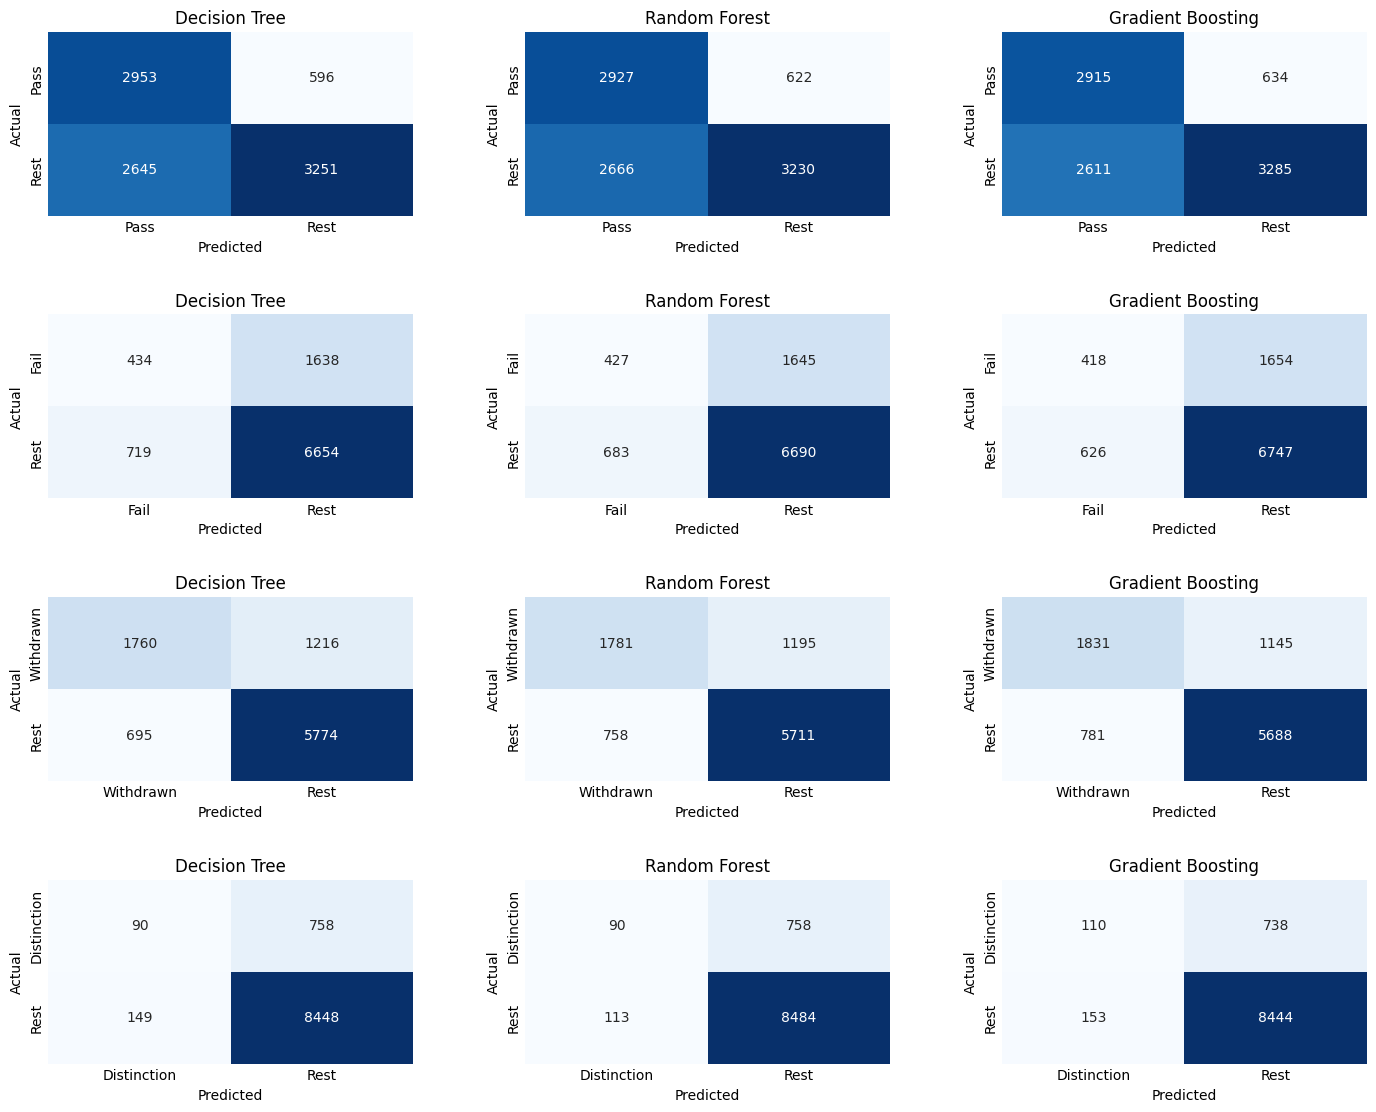

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

classes = ["Pass", "Fail", "Withdrawn", "Distinction"]

fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=len(models),
    figsize=(15, 12)
)
plt.tight_layout(pad=5.0)

for i, cls in enumerate(classes):
    y_test_bin = (y_test == cls).astype(int)

    for j, (model_name, y_pred) in enumerate(models.items()):
        y_pred_bin = (y_pred == cls).astype(int)
        cm = confusion_matrix(y_test_bin, y_pred_bin)

        TN, FP, FN, TP = cm.ravel()

        cm_plot = np.array([
            [TP, FN],
            [FP, TN]
        ])

        ax = axes[i, j]
        sns.heatmap(
            cm_plot,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=[cls, "Rest"],
            yticklabels=[cls, "Rest"],
            ax=ax
        )

        ax.set_title(f"{model_name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        # malo razmaka
        ax.tick_params(axis='both', which='both', length=0)

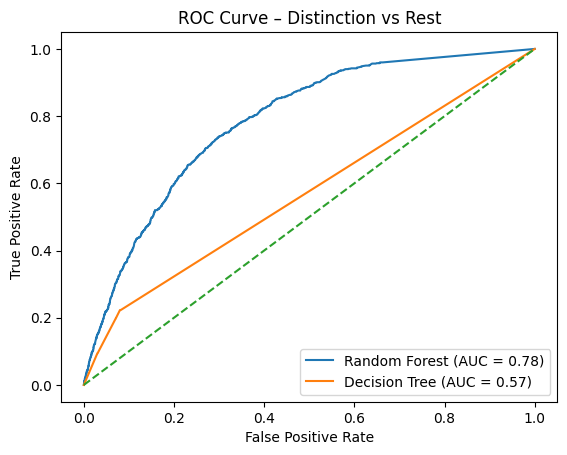

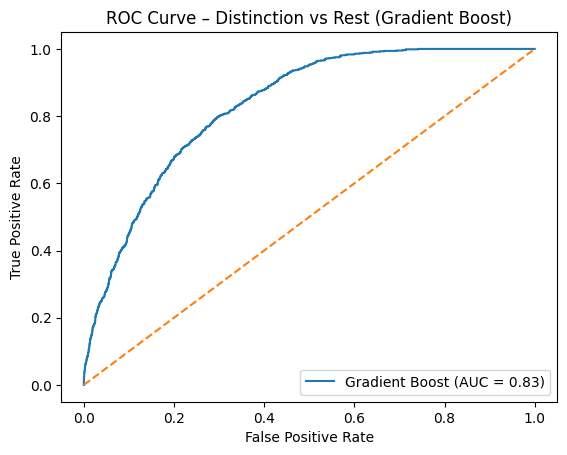

In [142]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

y_test_bin_dist = (y_test == "Distinction").astype(int)

rf_idx = list(rf_model.classes_).index("Distinction")
y_score_rf = rf_model.predict_proba(X_test)[:, rf_idx]

mask_rf = ~np.isnan(y_score_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin_dist[mask_rf], y_score_rf[mask_rf])
auc_rf = auc(fpr_rf, tpr_rf)

dt_idx = list(dt_model.classes_).index("Distinction")
y_score_dt = dt_model.predict_proba(X_test)[:, dt_idx]

mask_dt = ~np.isnan(y_score_dt)
fpr_dt, tpr_dt, _ = roc_curve(y_test_bin_dist[mask_dt], y_score_dt[mask_dt])
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Distinction vs Rest")
plt.legend()
plt.show()


gb_idx = list(gb_model.classes_).index("Distinction")

y_score_gb = gb_model.predict_proba(X_test)[:, gb_idx]

mask_gb = ~np.isnan(y_score_gb)

fpr_gb, tpr_gb, _ = roc_curve(
    y_test_bin_dist[mask_gb],
    y_score_gb[mask_gb]
)

auc_gb = auc(fpr_gb, tpr_gb)

plt.figure()
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boost (AUC = {auc_gb:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Distinction vs Rest (Gradient Boost)")
plt.legend()
plt.show()



## 5.2 Dodavanje novih značajki

Pri analizi skupa podataka, izdvojili smo nekoliko novih značajki koje je moguće koristiti pri klasifikaciji:
- `studied_credits`
- `delay_first_assessment`
- `active_days_before_course_start`
- `clicks_from_course_start_until_first_assessment`
- `active_days_from_course_start_until_first_assessment`
- `submitted_first_assignment`

Sve ove značajke poznate su prije prve provjere znanja na predmetu, što ih čini potencijalno korisnim pri ranom predviđanju uspjeha na predmetu. Neke su značajke bile odmah dostupne iz skupa podataka, dok su neke izvedene postupka inženjerstva značajki.

In [203]:
used_features_first_assessment = [
    'score_first_assessment',
    'highest_education',
    'clicks_till_course_starts',
    'date_registration',
    'age_band',
    'gender',
    'disability',
    'num_of_prev_attempts',
    'studied_credits',
    'delay_first_assessment',
    'active_days_before_course_start',
    'clicks_from_course_start_until_first_assessment',
    'active_days_from_course_start_until_first_assessment',
    'submitted_first_assignment'
]

X = data[used_features_first_assessment]
y = data['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [204]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

# Implementacije sva 3 modela
dt_model = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))
rf_model = OneVsRestClassifier(RandomForestClassifier(random_state=42))
gb_model = OneVsRestClassifier(GradientBoostingClassifier(random_state=42))

# Treniranje modela
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Testiranje modela
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

print("Gotovo treniranje i predikcija modela.")

Gotovo treniranje i predikcija modela.


In [205]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb  
}

classes = y_test.unique()
results = []

for cls in classes:
    for model_name, y_pred in models.items():
        y_test_bin = (y_test == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)
        
        prec = precision_score(y_test_bin, y_pred_bin)
        rec = recall_score(y_test_bin, y_pred_bin)
        f1 = f1_score(y_test_bin, y_pred_bin)
        acc = accuracy_score(y_test_bin, y_pred_bin)
        
        results.append({
            "Class": cls,
            "Model": model_name,
            "Precision": round(prec, 2),
            "Recall": round(rec, 2),
            "F1": round(f1, 2),
            "Accuracy": round(acc, 2)
        })
df_results = pd.DataFrame(results)

df_long = df_results.melt(
    id_vars=["Class", "Model"],
    value_vars=["Precision", "Recall", "F1", "Accuracy"],
    var_name="Metric",
    value_name="Value"
)
table = df_long.pivot_table(
    index=["Class", "Metric"],
    columns="Model",
    values="Value"
).round(2)

print(table)


Model                  Decision Tree  Gradient Boosting  Random Forest
Class       Metric                                                    
Distinction Accuracy            0.68               0.91           0.91
            F1                  0.21               0.14           0.20
            Precision           0.14               0.55           0.53
            Recall              0.48               0.08           0.12
Fail        Accuracy            0.69               0.77           0.76
            F1                  0.30               0.28           0.31
            Precision           0.30               0.45           0.41
            Recall              0.30               0.20           0.25
Pass        Accuracy            0.63               0.67           0.67
            F1                  0.43               0.66           0.66
            Precision           0.52               0.53           0.54
            Recall              0.36               0.88           0.84
Withdr

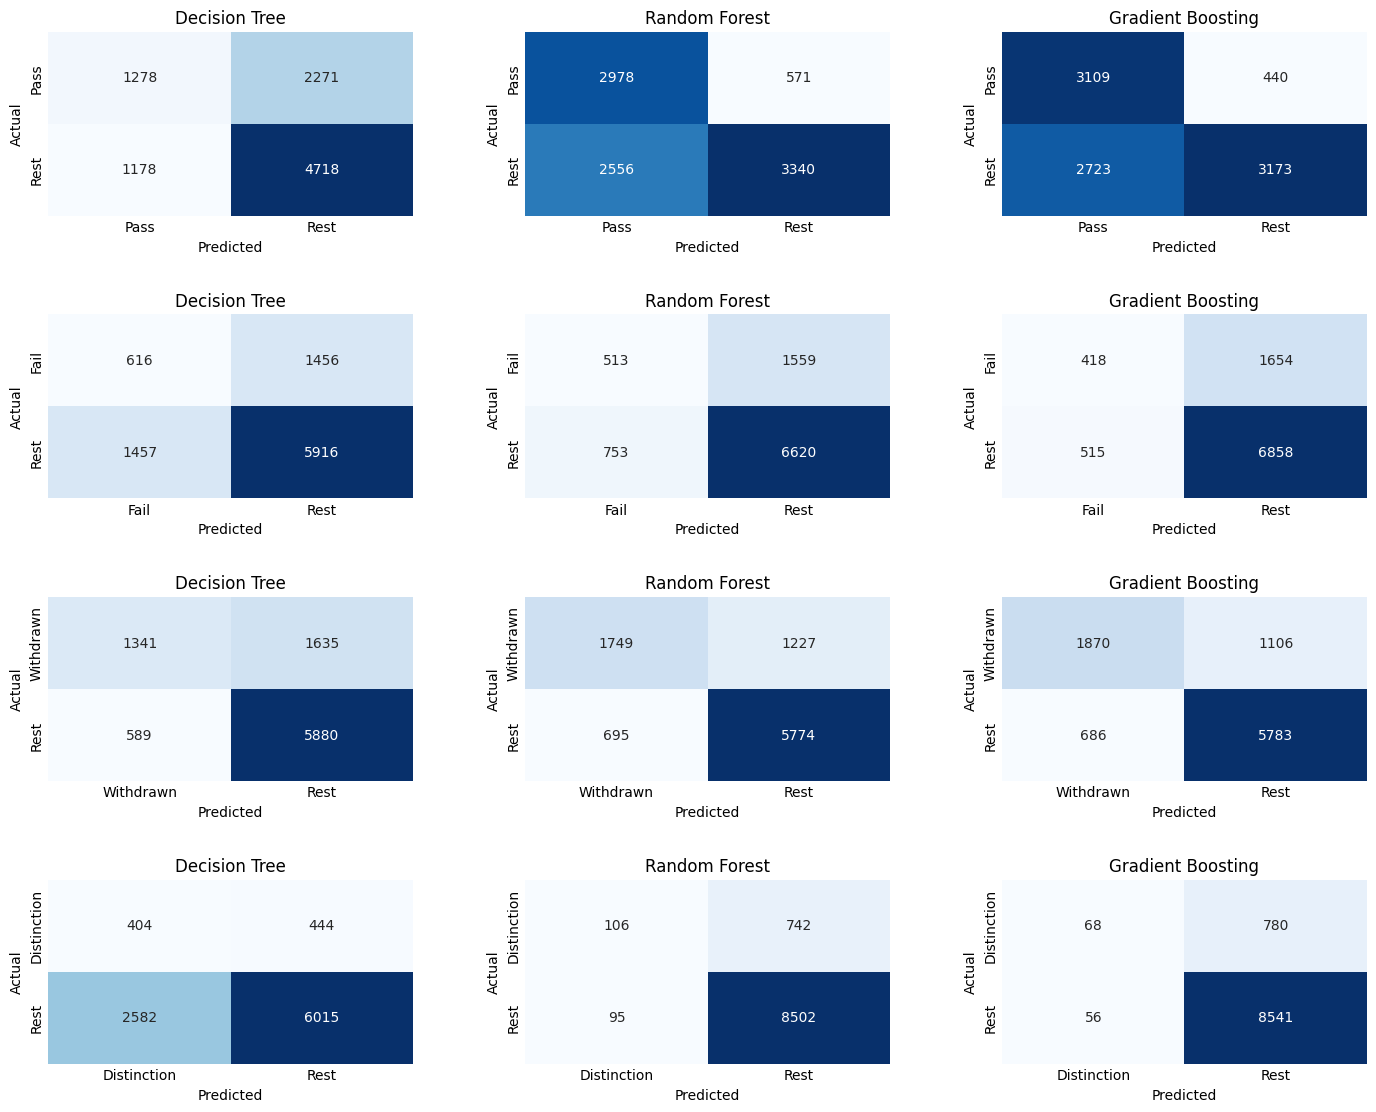

In [206]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

classes = ["Pass", "Fail", "Withdrawn", "Distinction"]

fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=len(models),
    figsize=(15, 12)
)
plt.tight_layout(pad=5.0)

for i, cls in enumerate(classes):
    y_test_bin = (y_test == cls).astype(int)

    for j, (model_name, y_pred) in enumerate(models.items()):
        y_pred_bin = (y_pred == cls).astype(int)
        cm = confusion_matrix(y_test_bin, y_pred_bin)

        TN, FP, FN, TP = cm.ravel()

        cm_plot = np.array([
            [TP, FN],
            [FP, TN]
        ])

        ax = axes[i, j]
        sns.heatmap(
            cm_plot,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=[cls, "Rest"],
            yticklabels=[cls, "Rest"],
            ax=ax
        )

        ax.set_title(f"{model_name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        # malo razmaka
        ax.tick_params(axis='both', which='both', length=0)

Dodavanjem novih značajki poboljšali smo sposobnost diskriminativnosti modela, čime se generalno poboljšao F1 score svih modela (unatoč djelomičnom smanjenju točnosti). 

# 5.3 Ostali modeli

Sljedeći logičan korak jest isprobavanjem drugačijih modela strojnog učenja s nadom da će moći bolje modelirati distribuciju podataka:
- Logistička regresija
- SVM
- XGBoost
- Neuronska mreža

### 5.3.1 Logistička regresija

/Users/jan/Desktop/fakultet/uzop/projekt/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/jan/Desktop/fakultet/uzop/projekt/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    htt

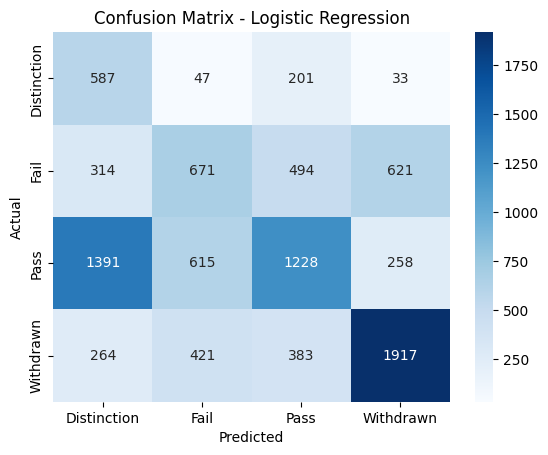

              precision    recall  f1-score   support

 Distinction       0.23      0.68      0.34       868
        Fail       0.38      0.32      0.35      2100
        Pass       0.53      0.35      0.42      3492
   Withdrawn       0.68      0.64      0.66      2985

    accuracy                           0.47      9445
   macro avg       0.46      0.50      0.44      9445
weighted avg       0.52      0.47      0.47      9445

Accuracy: 0.46617257808364215


In [145]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
logreg_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga']
}

lg_grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    logreg_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
lg_grid_search.fit(X_train, y_train)
best_lg_model = lg_grid_search.best_estimator_

y_pred = best_lg_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_lg_model.classes_,
            yticklabels=best_lg_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


### 5.3.2 SVM

/Users/jan/Desktop/fakultet/uzop/projekt/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best SVM parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}


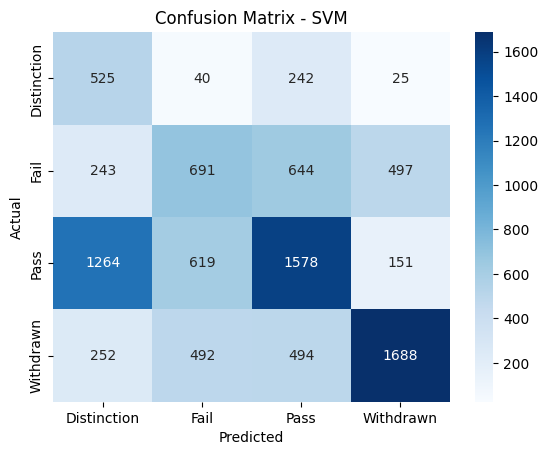

              precision    recall  f1-score   support

 Distinction       0.23      0.63      0.34       832
        Fail       0.38      0.33      0.35      2075
        Pass       0.53      0.44      0.48      3612
   Withdrawn       0.71      0.58      0.64      2926

    accuracy                           0.47      9445
   macro avg       0.46      0.49      0.45      9445
weighted avg       0.53      0.47      0.49      9445

Accuracy: 0.4745367919534145


In [146]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

svm_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

svm_grid_search = GridSearchCV(
    SVC(class_weight='balanced'),
    svm_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_grid_search.fit(X_train_scaled, y_train)
best_svm_model = svm_grid_search.best_estimator_
print("Best SVM parameters:", svm_grid_search.best_params_)

best_svm_model.fit(X_train_scaled, y_train)

y_pred = best_svm_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_svm_model.classes_,
            yticklabels=best_svm_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

### 5.3.4 Neuronska mreža

              precision    recall  f1-score   support

 Distinction       0.44      0.03      0.06       848
        Fail       0.42      0.20      0.27      2072
        Pass       0.52      0.88      0.66      3549
   Withdrawn       0.74      0.60      0.66      2976

    accuracy                           0.57      9445
   macro avg       0.53      0.43      0.41      9445
weighted avg       0.56      0.57      0.52      9445

Accuracy: 0.5671784012705136


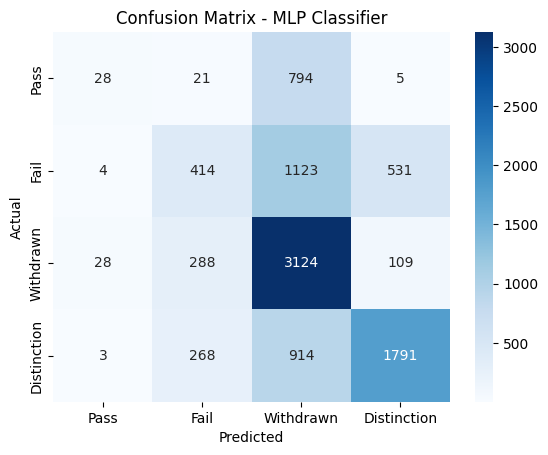

In [181]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

classes = ["Pass", "Fail", "Withdrawn", "Distinction"]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MLP Classifier")
plt.show()

Donekle iznenađujuće jest da neuronska mreža daje lošije rezultate od prethodnih modela.

### 5.3.3 XGBoost

XGBoost jedan je od najuspješnijih modela za zadatke klasifikacije kod tabličnih podataka.

Zbog specifičnosti implementacije metode za treniranje, za početak trebamo mapirati ciljnu varijablu iz tekstualne u numeričku.

In [174]:
y_train_mapped = y_train.map({'Pass': 0, 'Fail': 1, 'Withdrawn': 2, 'Distinction': 3})
y_train_mapped

13103    0
31058    1
995      2
3789     1
17173    1
        ..
3208     2
11720    2
32176    0
11790    1
30615    3
Name: final_result, Length: 22037, dtype: int64

In [175]:
y_test_mapped = y_test.map({'Pass': 0, 'Fail': 1, 'Withdrawn': 2, 'Distinction': 3})
y_test_mapped

11178    0
15302    2
4149     1
24484    2
28343    2
        ..
1298     0
17166    0
20770    3
14853    0
31691    2
Name: final_result, Length: 9445, dtype: int64

/Users/jan/Desktop/fakultet/uzop/projekt/.venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [22:05:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.54      0.48      0.51      3549
           1       0.35      0.36      0.36      2072
           2       0.72      0.59      0.65      2976
           3       0.25      0.53      0.34       848

    accuracy                           0.49      9445
   macro avg       0.47      0.49      0.46      9445
weighted avg       0.53      0.49      0.50      9445

Accuracy: 0.4903123345685548


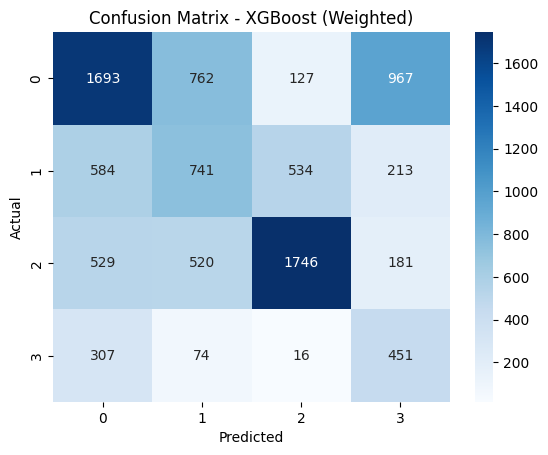

In [176]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

xgb_model = xgb.XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss',
    objective='multi:softprob' 
)

xgb_model.fit(X_train, y_train_mapped, sample_weight=sample_weights)

y_pred = xgb_model.predict(X_test)

print(classification_report(y_test_mapped, y_pred))
print("Accuracy:", accuracy_score(y_test_mapped, y_pred))

cm = confusion_matrix(y_test_mapped, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1, 2, 3],
            yticklabels=[0, 1, 2, 3])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost (Weighted)")
plt.show()

Lijepo je :)

XGBoost je rezultirao najvećom F1 mjerom od svih korištenih modela. Iz matrice konfuzije oučljive su i vrijednosti na dijagoni, što ukazuje na to da algoritam najbolje razlikuje između klasa.

Zbog navedenog, u daljnjim poboljšanjima rezultata, razmatrat ćemo samo XGBoosta.

# 5.4 SMOTE

S obzirom na nebalansiranost klasa, odlučili smo koristiti metodu SMOTE (*Synthetic minority oversampling technique*) za naduzorkovanje manje zastupljenih klasa. Potom smo, radi s usporedbe s člankom, ponovno istrenirali početne modele.

In [182]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# SMOTE ide samo na train skup uvijek!
print("Prije SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

dt_model_smote = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))
rf_model_smote = OneVsRestClassifier(RandomForestClassifier(random_state=42))
gb_model_smote = OneVsRestClassifier(GradientBoostingClassifier(random_state=42))

print("Poslije SMOTE:", Counter(y_train_smote))
dt_model_smote.fit(X_train_smote, y_train_smote)
rf_model_smote.fit(X_train_smote, y_train_smote)
gb_model_smote.fit(X_train_smote, y_train_smote)

y_pred_dt_smote = dt_model_smote.predict(X_test)
y_pred_rf_smote = rf_model_smote.predict(X_test)
y_pred_gb_smote = gb_model_smote.predict(X_test)

Prije SMOTE: Counter({'Pass': 8281, 'Withdrawn': 6944, 'Fail': 4835, 'Distinction': 1977})
Poslije SMOTE: Counter({'Pass': 8281, 'Fail': 8281, 'Withdrawn': 8281, 'Distinction': 8281})


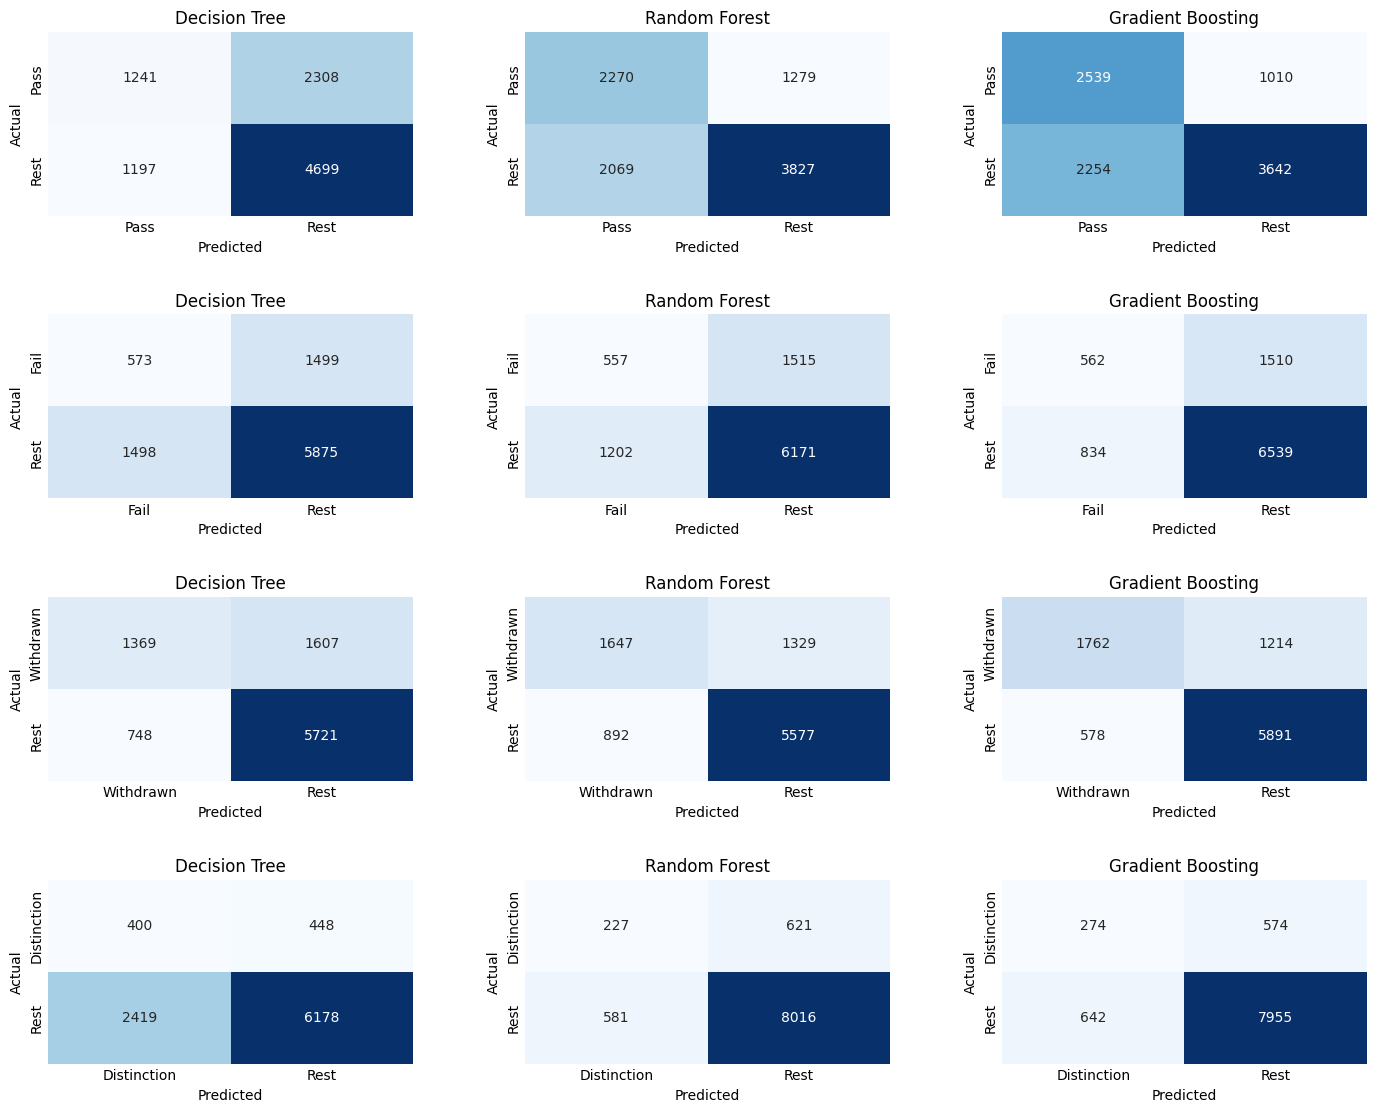

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

models = {
    "Decision Tree": y_pred_dt_smote,
    "Random Forest": y_pred_rf_smote,
    "Gradient Boosting": y_pred_gb_smote
}

classes = ["Pass", "Fail", "Withdrawn", "Distinction"]

fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=len(models),
    figsize=(15, 12)
)
plt.tight_layout(pad=5.0)

for i, cls in enumerate(classes):
    y_test_bin = (y_test == cls).astype(int)

    for j, (model_name, y_pred) in enumerate(models.items()):
        y_pred_bin = (y_pred == cls).astype(int)
        cm = confusion_matrix(y_test_bin, y_pred_bin)

        TN, FP, FN, TP = cm.ravel()

        cm_plot = np.array([
            [TP, FN],
            [FP, TN]
        ])

        ax = axes[i, j]
        sns.heatmap(
            cm_plot,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=[cls, "Rest"],
            yticklabels=[cls, "Rest"],
            ax=ax
        )

        ax.set_title(f"{model_name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        # malo razmaka
        ax.tick_params(axis='both', which='both', length=0)

In [185]:
from sklearn.metrics import classification_report

print("=== Random Forest bez SMOTE ===")
print(classification_report(y_test, y_pred_rf))

print("=== Random Forest sa SMOTE ===")
print(classification_report(y_test, y_pred_rf_smote))

=== Random Forest bez SMOTE ===
              precision    recall  f1-score   support

 Distinction       0.44      0.11      0.17       848
        Fail       0.38      0.21      0.27      2072
        Pass       0.52      0.82      0.64      3549
   Withdrawn       0.70      0.60      0.65      2976

    accuracy                           0.55      9445
   macro avg       0.51      0.43      0.43      9445
weighted avg       0.54      0.55      0.52      9445

=== Random Forest sa SMOTE ===
              precision    recall  f1-score   support

 Distinction       0.28      0.27      0.27       848
        Fail       0.32      0.27      0.29      2072
        Pass       0.52      0.64      0.58      3549
   Withdrawn       0.65      0.55      0.60      2976

    accuracy                           0.50      9445
   macro avg       0.44      0.43      0.43      9445
weighted avg       0.50      0.50      0.49      9445



Iako su globalne metrike ostale slične, vidljivo je poboljšanje u odzivu i F1 mjeri kod inicijalno podzastupljenih klasa, što i jest svrha metoda poput SMOTE-a. 

# 6. Dodatna razmatranja

## 6.1 Korištenje podataka iz kasnijih trenutaka kolegija

Pitanje na koje želimo odgovoriti u sklopu ovog projekta jest poboljšava li se prediktivna moć ako koristimo podatke iz kasnijih trenutaka kolegija. 

Za to definiramo tri slučaja:
- aktivnosti studenta do prve provjere znanja,
- aktivnosti studenta do polovice kolegija,
- aktivnosti studenta do posljednje četvrtine semestra

Za testiranje naše pretpostavke da kasniji podatci omogućuju bolja predviđanja trenirat ćemo tri XGBoost modela, po jedan za svaki od gore navedenih slučajeva.

In [194]:
data.describe()

,id_student,highest_education,age_band,gender,disability,num_of_prev_attempts,studied_credits,date_registration,score_first_assessment,delay_first_assessment,cumulative_score_half,cumulative_score_3q,clicks_till_course_starts,active_days_before_course_start,clicks_from_course_start_until_first_assessment,active_days_from_course_start_until_first_assessment,clicks_from_course_start_until_half,submitted_first_assignment
count,3.148200e+04,31482.000000,31482.000000,31482.000000,31482.000000,31482.000000,31482.000000,31482.00000,31482.000000,31482.000000,31482.000000,31482.000000,31482.000000,31482.000000,31482.000000,31482.000000,31482.000000,31482.000000
mean,7.069493e+05,0.747602,0.298933,0.457881,0.099454,0.164507,79.767804,-69.81364,56.286449,223.647862,199.646242,264.286799,64.256400,3.245505,206.585414,7.964043,668.058192,0.774951
std,5.505441e+05,0.711673,0.471538,0.498231,0.299275,0.482633,41.049455,49.16707,35.736009,417.879506,165.260450,226.874285,126.954325,3.787834,267.753002,6.673819,938.710408,0.417621
min,3.733000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,-322.00000,0.000000,-62.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.076005e+05,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,-101.00000,1.000000,-2.000000,58.000000,59.000000,0.000000,0.000000,28.000000,3.000000,87.250000,1.000000
50%,5.898190e+05,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,-57.00000,70.000000,0.000000,194.000000,244.000000,18.000000,2.000000,120.000000,7.000000,351.000000,1.000000
75%,6.441622e+05,1.000000,1.000000,1.000000,0.000000,0.000000,120.000000,-29.00000,84.000000,7.000000,286.000000,398.000000,74.000000,5.000000,287.000000,12.000000,853.000000,1.000000
max,2.716795e+06,3.000000,2.000000,1.000000,1.000000,6.000000,655.000000,167.00000,100.000000,999.000000,785.000000,1072.000000,3731.000000,25.000000,5643.000000,62.000000,13086.000000,1.000000


In [208]:
used_features_first_assessment = [
    'score_first_assessment',
    'highest_education',
    'clicks_till_course_starts',
    'date_registration',
    'age_band',
    'gender',
    'disability',
    'num_of_prev_attempts',
    'studied_credits',
    'delay_first_assessment',
    'active_days_before_course_start',
    'clicks_from_course_start_until_first_assessment',
    'active_days_from_course_start_until_first_assessment',
    'submitted_first_assignment'
]

used_features_half_course = [
    'score_first_assessment',
    'highest_education',
    'clicks_till_course_starts',
    'date_registration',
    'age_band',
    'gender',
    'disability',
    'num_of_prev_attempts',
    'studied_credits',
    'delay_first_assessment',
    'active_days_before_course_start',
    'active_days_from_course_start_until_first_assessment',
    'submitted_first_assignment',
    'cumulative_score_half',
    'clicks_from_course_start_until_half',
]

used_features_3q = [
    'score_first_assessment',
    'highest_education',
    'clicks_till_course_starts',
    'date_registration',
    'age_band',
    'gender',
    'disability',
    'num_of_prev_attempts',
    'studied_credits',
    'delay_first_assessment',
    'active_days_before_course_start',
    'active_days_from_course_start_until_first_assessment',
    'submitted_first_assignment',
    'cumulative_score_3q',
]

In [209]:
scores = {
    'Pass': [],
    'Fail': [],
    'Withdrawn': [],
    'Distinction': []
}
model_names = ['First Assessment', 'Half Course', '3rd Quarter']

/Users/jan/Desktop/fakultet/uzop/projekt/.venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [23:41:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.56      0.48      0.52      3549
           1       0.38      0.43      0.40      2072
           2       0.74      0.58      0.65      2976
           3       0.28      0.54      0.37       848

    accuracy                           0.51      9445
   macro avg       0.49      0.51      0.49      9445
weighted avg       0.55      0.51      0.52      9445

Accuracy: 0.5094759131815776


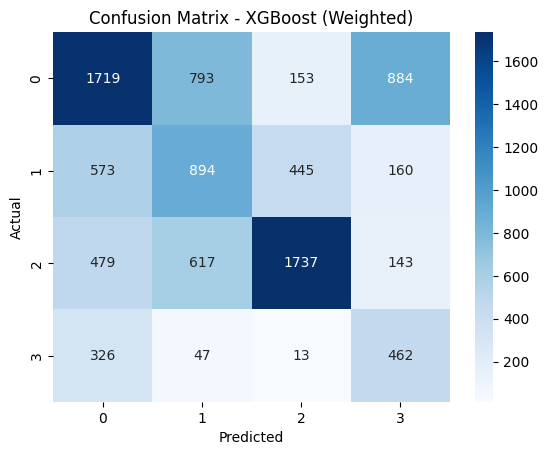

In [210]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

X = data[used_features_first_assessment]
y = data['final_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
y_train_mapped = y_train.map({'Pass': 0, 'Fail': 1, 'Withdrawn': 2, 'Distinction': 3})
y_test_mapped = y_test.map({'Pass': 0, 'Fail': 1, 'Withdrawn': 2, 'Distinction': 3})

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

xgb_model = xgb.XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss',
    objective='multi:softprob' 
)

xgb_model.fit(X_train, y_train_mapped, sample_weight=sample_weights)

y_pred = xgb_model.predict(X_test)

report = classification_report(y_test_mapped, y_pred, output_dict=True)
scores['Pass'].append(report['0']['f1-score'])
scores['Fail'].append(report['1']['f1-score'])
scores['Withdrawn'].append(report['2']['f1-score'])
scores['Distinction'].append(report['3']['f1-score'])

print(classification_report(y_test_mapped, y_pred))
print("Accuracy:", accuracy_score(y_test_mapped, y_pred))

cm = confusion_matrix(y_test_mapped, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1, 2, 3],
            yticklabels=[0, 1, 2, 3])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost (Weighted)")
plt.show()

/Users/jan/Desktop/fakultet/uzop/projekt/.venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [23:41:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.69      0.64      0.67      3549
           1       0.44      0.46      0.45      2072
           2       0.76      0.67      0.71      2976
           3       0.40      0.65      0.50       848

    accuracy                           0.61      9445
   macro avg       0.57      0.61      0.58      9445
weighted avg       0.63      0.61      0.62      9445

Accuracy: 0.6115404976177872


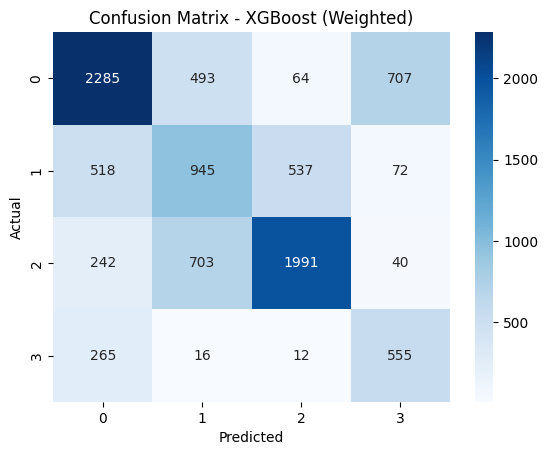

In [211]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

X = data[used_features_half_course]
y = data['final_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
y_train_mapped = y_train.map({'Pass': 0, 'Fail': 1, 'Withdrawn': 2, 'Distinction': 3})
y_test_mapped = y_test.map({'Pass': 0, 'Fail': 1, 'Withdrawn': 2, 'Distinction': 3})

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

xgb_model = xgb.XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss',
    objective='multi:softprob' 
)

xgb_model.fit(X_train, y_train_mapped, sample_weight=sample_weights)

y_pred = xgb_model.predict(X_test)

report = classification_report(y_test_mapped, y_pred, output_dict=True)
scores['Pass'].append(report['0']['f1-score'])
scores['Fail'].append(report['1']['f1-score'])
scores['Withdrawn'].append(report['2']['f1-score'])
scores['Distinction'].append(report['3']['f1-score'])

print(classification_report(y_test_mapped, y_pred))
print("Accuracy:", accuracy_score(y_test_mapped, y_pred))

cm = confusion_matrix(y_test_mapped, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1, 2, 3],
            yticklabels=[0, 1, 2, 3])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost (Weighted)")
plt.show()

/Users/jan/Desktop/fakultet/uzop/projekt/.venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [23:41:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.73      0.68      0.70      3549
           1       0.46      0.46      0.46      2072
           2       0.77      0.70      0.73      2976
           3       0.43      0.69      0.53       848

    accuracy                           0.64      9445
   macro avg       0.60      0.63      0.61      9445
weighted avg       0.65      0.64      0.64      9445

Accuracy: 0.6380095288512441


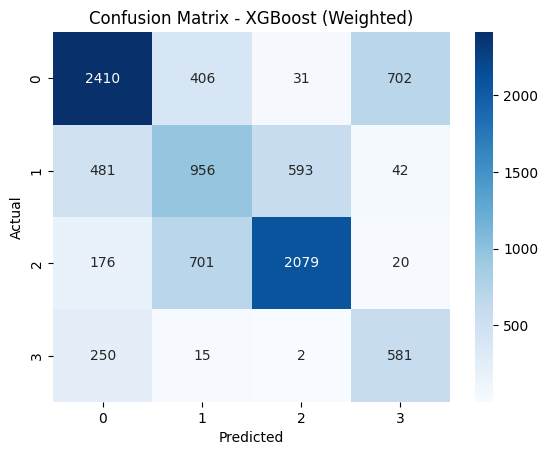

In [212]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

X = data[used_features_3q]
y = data['final_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
y_train_mapped = y_train.map({'Pass': 0, 'Fail': 1, 'Withdrawn': 2, 'Distinction': 3})
y_test_mapped = y_test.map({'Pass': 0, 'Fail': 1, 'Withdrawn': 2, 'Distinction': 3})

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

xgb_model = xgb.XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss',
    objective='multi:softprob' 
)

xgb_model.fit(X_train, y_train_mapped, sample_weight=sample_weights)

y_pred = xgb_model.predict(X_test)

report = classification_report(y_test_mapped, y_pred, output_dict=True)
scores['Pass'].append(report['0']['f1-score'])
scores['Fail'].append(report['1']['f1-score'])
scores['Withdrawn'].append(report['2']['f1-score'])
scores['Distinction'].append(report['3']['f1-score'])

print(classification_report(y_test_mapped, y_pred))
print("Accuracy:", accuracy_score(y_test_mapped, y_pred))

cm = confusion_matrix(y_test_mapped, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1, 2, 3],
            yticklabels=[0, 1, 2, 3])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost (Weighted)")
plt.show()

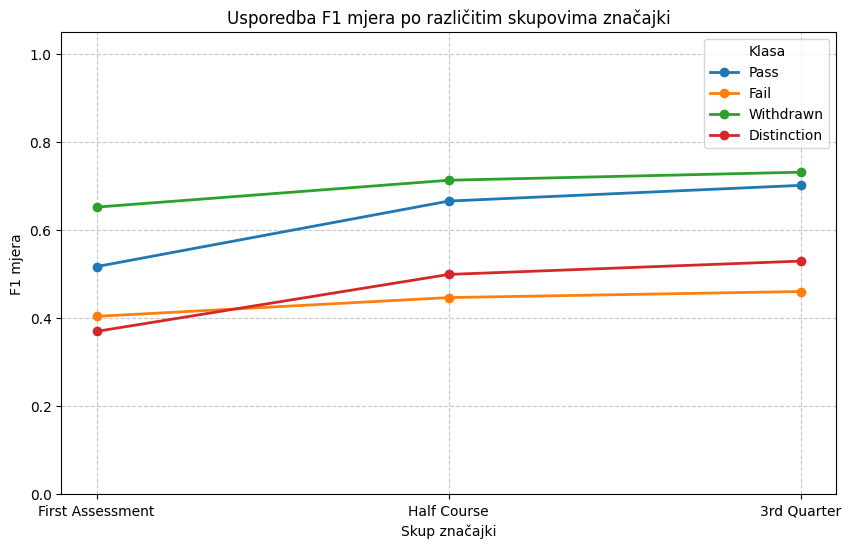

In [213]:
plt.figure(figsize=(10, 6))

for class_name, scores in scores.items():
    plt.plot(model_names, scores, marker='o', linewidth=2, label=class_name)

plt.title("Usporedba F1 mjera po različitim skupovima značajki")
plt.xlabel("Skup značajki")
plt.ylabel("F1 mjera")
plt.ylim(0, 1.05) # Fix y-axis to 0-1 range
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Klasa")
plt.show()

Vidljivo je poboljšanje metrika kod korištenja podataka iz kasnijih trenutaka predmeta, što je i očekivano iz inicijalne pretpostavke. Kako se bliži kraj predmeta, to je izvjesniji rezultat studenta.

Ovi se rezultati mogu koristiti za kontinuirane intervencije tijekom semestra (npr. nakon međuispita ili netom prije završnih ispita).

## 6.2 Razdvajanje skupa podataka prema predmetima

Ideja iza ovog odjeljka jest da je za različite predmete značajke različito utječu na rezultat studenta.

Razdvojili smo skup podataka prema identifikatoru predmeta i za svaki trenirali zaseban XGBoost model.

In [215]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt
import xgboost as xgb


TARGET = "final_result"
MODULE_COL = "code_module"          # samo po modulu
PRESENT_COL = "code_presentation"   # ostaje u df, ali se ne koristi kao feature
ID_COLS = ["id_student"]

CLASS_ORDER = ["Pass", "Fail", "Withdrawn", "Distinction"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_ORDER)}

DROPNA_COLS = ["imd_band"]                 # drop redaka gdje je imd_band missing
DATE_REG_COL = "date_registration"         # imputacija medijanom
DELAY_COL = "delay_first_assessment"       # indikator + imputacija 999
HAS_FA_COL = "has_first_assessment"        # 1 ako delay postoji, 0 ako je missing


In [216]:
def prepare_df(df_in: pd.DataFrame) -> pd.DataFrame:
    d = df_in.copy()

    for c in DROPNA_COLS:
        if c in d.columns:
            d = d.dropna(subset=[c])

    if DELAY_COL in d.columns:
        d[HAS_FA_COL] = (~d[DELAY_COL].isna()).astype(int)
        d[DELAY_COL] = d[DELAY_COL].fillna(999)

    if DATE_REG_COL in d.columns:
        med = d[DATE_REG_COL].median()
        d[DATE_REG_COL] = d[DATE_REG_COL].fillna(med)
        
    if TARGET in d.columns:
        d = d[d[TARGET].isin(CLASS_ORDER)].copy()

    return d

In [217]:
def build_preprocessor(df_any: pd.DataFrame) -> ColumnTransformer:
    exclude = set([TARGET, MODULE_COL, PRESENT_COL] + ID_COLS + ["imd_band"])

    cat_cols = [
        c for c in df_any.columns
        if df_any[c].dtype == "object" and c not in exclude
    ]

    num_cols = [
        c for c in df_any.columns
        if np.issubdtype(df_any[c].dtype, np.number) and c not in exclude
    ]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre

In [218]:
def train_eval_xgb_for_module(
    df_module: pd.DataFrame,
    module_name: str,
    test_size: float = 0.3,
    seed: int = 42
):
    d = prepare_df(df_module)
    if len(d) == 0:
        return None

    y = d[TARGET].map(CLASS_TO_ID)
    X = d.drop(columns=[TARGET])

    vc = y.value_counts()
    can_stratify = (vc.shape[0] >= 2) and (vc.min() >= 2)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=seed,
        stratify=y if can_stratify else None,
    )

    pre = build_preprocessor(pd.concat([X_train, X_test], axis=0))

    sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

    model = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(CLASS_ORDER),
        eval_metric="mlogloss",
        random_state=seed,
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        tree_method="hist",
    )

    pipe = Pipeline(steps=[
        ("pre", pre),
        ("clf", model),
    ])

    pipe.fit(X_train, y_train, clf__sample_weight=sample_weights)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    report = classification_report(
        y_test, y_pred,
        labels=list(range(len(CLASS_ORDER))),
        target_names=CLASS_ORDER,
        digits=3,
        zero_division=0,
    )

    cm = confusion_matrix(y_test, y_pred, labels=list(range(len(CLASS_ORDER))))

    return {
        "module": module_name,
        "rows": len(d),
        "train": len(X_train),
        "test": len(X_test),
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "macro_f1": macro_f1,
        "report": report,
        "cm": cm,
        "stratify_used": can_stratify,
    }

In [219]:
def run_per_module_xgb(df_all: pd.DataFrame, seed: int = 42, min_rows: int = 200):
    results = []

    modules = sorted(df_all[MODULE_COL].dropna().unique().tolist())

    for m in modules:
        df_m = df_all[df_all[MODULE_COL] == m].copy()
        out = train_eval_xgb_for_module(df_m, module_name=m, seed=seed)

        if out is None:
            continue
        if out["rows"] < min_rows:
            continue

        results.append(out)

        print("\n" + "=" * 70)
        print(f"MODULE: {out['module']} | rows={out['rows']} train={out['train']} test={out['test']}")
        print(f"stratify_used: {out['stratify_used']}")
        print(f"accuracy={out['accuracy']:.3f} balanced_accuracy={out['balanced_accuracy']:.3f} macro_f1={out['macro_f1']:.3f}")
        print("\nclassification report:")
        print(out["report"])

        disp = ConfusionMatrixDisplay(confusion_matrix=out["cm"], display_labels=CLASS_ORDER)
        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, values_format="d")
        ax.set_title(f"Confusion matrix - module {out['module']}")
        plt.tight_layout()
        plt.show()

    if not results:
        return pd.DataFrame()

    summary = pd.DataFrame([{
        "module": r["module"],
        "rows": r["rows"],
        "train": r["train"],
        "test": r["test"],
        "accuracy": r["accuracy"],
        "balanced_accuracy": r["balanced_accuracy"],
        "macro_f1": r["macro_f1"],
        "stratify_used": r["stratify_used"],
    } for r in results]).sort_values(["macro_f1", "balanced_accuracy"], ascending=False)

    return summary


MODULE: AAA | rows=725 train=507 test=218
stratify_used: True
accuracy=0.780 balanced_accuracy=0.628 macro_f1=0.614

classification report:
              precision    recall  f1-score   support

        Pass      0.883     0.901     0.892       142
        Fail      0.500     0.296     0.372        27
   Withdrawn      0.659     0.730     0.692        37
 Distinction      0.438     0.583     0.500        12

    accuracy                          0.780       218
   macro avg      0.620     0.628     0.614       218
weighted avg      0.773     0.780     0.772       218



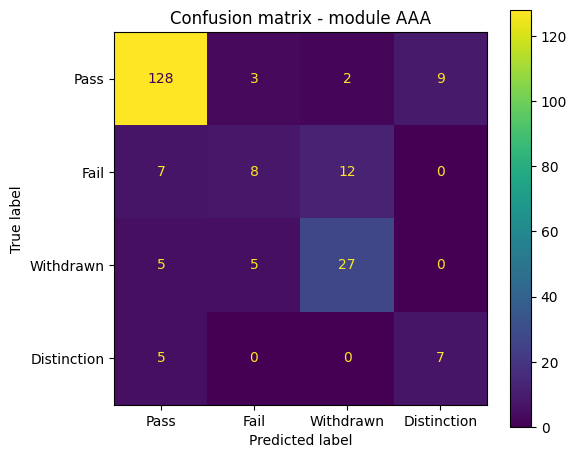


MODULE: BBB | rows=7846 train=5492 test=2354
stratify_used: True
accuracy=0.695 balanced_accuracy=0.647 macro_f1=0.643

classification report:
              precision    recall  f1-score   support

        Pass      0.757     0.788     0.772       914
        Fail      0.535     0.480     0.506       527
   Withdrawn      0.784     0.778     0.781       713
 Distinction      0.486     0.540     0.512       200

    accuracy                          0.695      2354
   macro avg      0.641     0.647     0.643      2354
weighted avg      0.692     0.695     0.693      2354



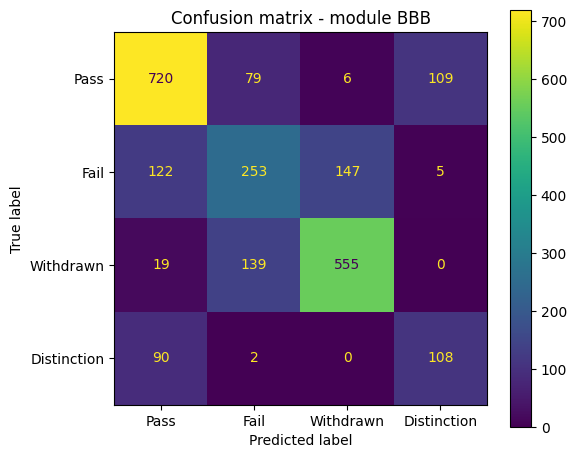


MODULE: CCC | rows=4180 train=2926 test=1254
stratify_used: True
accuracy=0.695 balanced_accuracy=0.643 macro_f1=0.637

classification report:
              precision    recall  f1-score   support

        Pass      0.686     0.748     0.716       330
        Fail      0.365     0.312     0.337       224
   Withdrawn      0.823     0.814     0.819       571
 Distinction      0.657     0.698     0.677       129

    accuracy                          0.695      1254
   macro avg      0.633     0.643     0.637      1254
weighted avg      0.688     0.695     0.691      1254



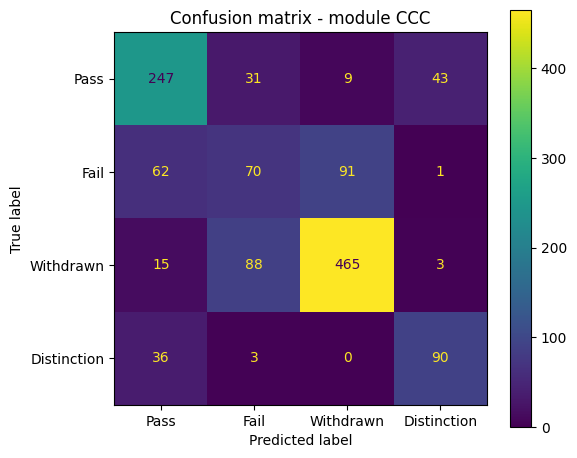


MODULE: DDD | rows=5992 train=4194 test=1798
stratify_used: True
accuracy=0.687 balanced_accuracy=0.611 macro_f1=0.618

classification report:
              precision    recall  f1-score   support

        Pass      0.739     0.812     0.774       626
        Fail      0.480     0.459     0.469       414
   Withdrawn      0.783     0.753     0.768       656
 Distinction      0.512     0.422     0.462       102

    accuracy                          0.687      1798
   macro avg      0.629     0.611     0.618      1798
weighted avg      0.683     0.687     0.684      1798



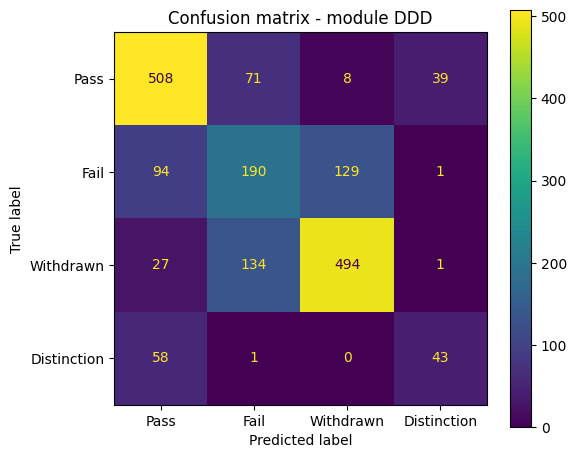


MODULE: EEE | rows=2817 train=1971 test=846
stratify_used: True
accuracy=0.669 balanced_accuracy=0.616 macro_f1=0.613

classification report:
              precision    recall  f1-score   support

        Pass      0.771     0.773     0.772       370
        Fail      0.507     0.451     0.477       164
   Withdrawn      0.711     0.731     0.721       212
 Distinction      0.459     0.510     0.483       100

    accuracy                          0.669       846
   macro avg      0.612     0.616     0.613       846
weighted avg      0.668     0.669     0.668       846



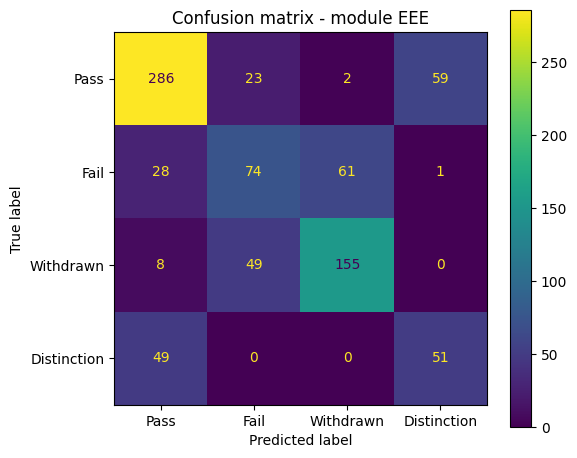


MODULE: FFF | rows=7395 train=5176 test=2219
stratify_used: True
accuracy=0.712 balanced_accuracy=0.715 macro_f1=0.691

classification report:
              precision    recall  f1-score   support

        Pass      0.804     0.793     0.799       835
        Fail      0.515     0.480     0.497       498
   Withdrawn      0.774     0.749     0.761       701
 Distinction      0.610     0.838     0.706       185

    accuracy                          0.712      2219
   macro avg      0.676     0.715     0.691      2219
weighted avg      0.714     0.712     0.711      2219



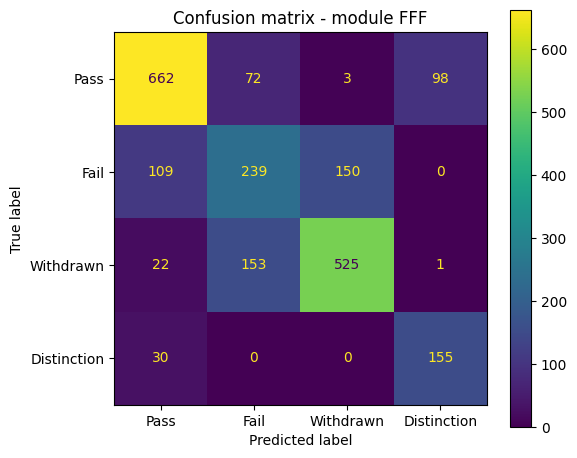


MODULE: GGG | rows=2527 train=1768 test=759
stratify_used: True
accuracy=0.613 balanced_accuracy=0.551 macro_f1=0.550

classification report:
              precision    recall  f1-score   support

        Pass      0.691     0.728     0.709       335
        Fail      0.685     0.638     0.660       218
   Withdrawn      0.532     0.568     0.549        88
 Distinction      0.294     0.271     0.282       118

    accuracy                          0.613       759
   macro avg      0.550     0.551     0.550       759
weighted avg      0.609     0.613     0.610       759



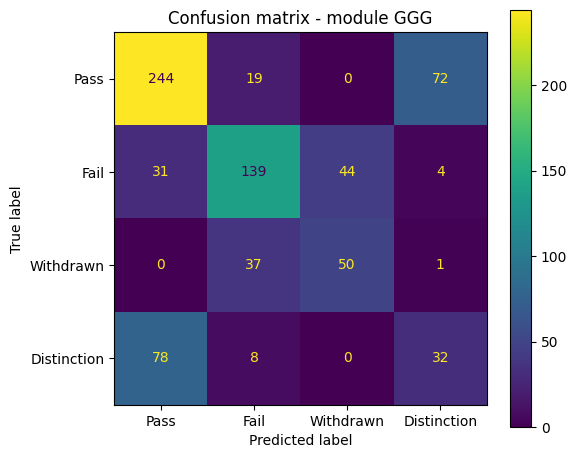

,module,rows,train,test,accuracy,balanced_accuracy,macro_f1,stratify_used
5,FFF,7395,5176,2219,0.712483,0.714875,0.690751,True
1,BBB,7846,5492,2354,0.694987,0.646556,0.642777,True
2,CCC,4180,2926,1254,0.695375,0.643255,0.636959,True
3,DDD,5992,4194,1798,0.686874,0.611264,0.618245,True
0,AAA,725,507,218,0.779817,0.627692,0.614097,True
4,EEE,2817,1971,846,0.669031,0.616331,0.613423,True
6,GGG,2527,1768,759,0.612648,0.551335,0.550256,True


In [220]:
summary = run_per_module_xgb(df, seed=42, min_rows=200)
summary


Prema rezultatima, jasno je da je naša inicijalna pretpostavka ispravna. Svaki modul (predmet) ima značajno veću vrijenost F1 mjere kad se trenira zasebno, što upućuje da su predmeti dovoljno heterogeni da su različite značajke korisne pri predviđanjima.